# **" Statistical Analysis of Geographic E-Commerce Disparity "**
*Do Rural Buyers Experience Worse Outcomes? A Statistical Analysis of Geographic Inequality in E-Commerce*

### **Context**
In e‑commerce, there is a common belief that rural customers face disadvantages compared to urban shoppers. The narrative often mentions slower deliveries, lower product quality, or less reliable service. Rather than relying on anecdotes, I wanted to test this assumption using actual transaction data to see if rural buyers truly experience a different pattern.

### **Analytical Plan**
The approach was straightforward: take purchase records, segment customers by location, and examine whether rural buyers show distinct behaviors. A key focus was on **repeat purchases** do rural customers return to buy the same product less often? If differences exist, the next step is to identify the driver: is it location itself, or other factors such as income levels or product categories?

### **Dataset Choice**
While the initial intent was to use an Indian dataset, no public source offered sufficient detail. Instead, I selected a well documented U.S. dataset from the **Harvard Dataverse**, which includes Amazon order records, customer survey data, and state level population density. Although the geography differs, the analytical framework remains the same: segment by urban vs rural and let the numbers reveal whether the perceived rural disadvantage holds true.


## A | **SETUP & DATA LOADING**

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

#### **Libraries Used**
I relied on a set of Python libraries to handle different parts of the analysis:

- *Pandas*: Core engine for tables, merges, grouping, and time operations.  
- *Numpy*: Quick numeric tasks such as log transforms and bin ranges.  
- *Matplotlib & Seaborn*: Visualization tools like Matplotlib for fine control, Seaborn for clean charts with minimal code.  

#### Specialized Helpers
A few focused libraries added analytical depth:

- *Missingno*: Visual maps of missing data, reducing guesswork.  
- *Scipy.stats*: Formal hypothesis tests (e.g., chi‑square, Mann‑Whitney U).  
- *Statsmodels*: Logistic regression with full statistical summaries.  
- *sklearn.metrics*: One‑line evaluation metrics like AUC and balanced accuracy.  


In [2]:
# import packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_curve
)


#sns.set_theme(style="whitegrid")

In [3]:
base_path = '/content/drive/MyDrive/Harvard Dataverse_ E-Commerce 1.0/'

orders = pd.read_csv(base_path + 'amazon-purchases.csv')
survey = pd.read_csv(base_path + 'survey.csv')
density = pd.read_csv(base_path + 'us_state_density_tiers.csv')


### *1. Orders table summery*

The dataset’s core is the **orders table**. The original file named it *purchase*, but I renamed it to *orders* for clarity and consistency. Each row represents a single order and contains key details: product purchased, cost, quantity, category, and the state where it was shipped.  

This table is central to the analysis because **repeat purchase behavior** must be derived from these sequences of orders. By tracking what customers buy again, and under what conditions, the table provides the foundation for measuring loyalty and identifying differences across segments.


In [4]:
print("\n_____ 1.  Orders Table — Column Overview _____")
print('orders table shape:', orders.shape, '\n')

inspection_rows = []
for col in orders.columns:
    inspection_rows.append({
        "Column"       : col,
        "Dtype"        : str(orders[col].dtype),
        "Null Count"   : orders[col].isna().sum(),
        "Null %"       : f"{orders[col].isna().sum()/len(orders)*100:.1f}%",
        "Unique Values": orders[col].nunique(),
        "Range"        : f"{orders[col].min():,.2f} – {orders[col].max():,.2f}"
                          if orders[col].dtype in [np.float64, np.int64] else "—",
        "Percentile"   : (
            f"{orders[col].quantile(0.25):,.2f} : "
            f"{orders[col].quantile(0.50):,.2f} : "
            f"{orders[col].quantile(0.75):,.2f}"
            if orders[col].dtype in [np.float64, np.int64] else "—"
        )
    })

schema_df = pd.DataFrame(inspection_rows)
print(schema_df.to_string())



_____ 1.  Orders Table — Column Overview _____
orders table shape: (1850717, 8) 

                     Column    Dtype  Null Count Null %  Unique Values            Range            Percentile
0                Order Date   object           0   0.0%           1913                —                     —
1   Purchase Price Per Unit  float64           0   0.0%          18282  0.01 – 6,398.95  8.47 : 13.99 : 23.75
2                  Quantity  float64           0   0.0%             69    1.00 – 339.00    1.00 : 1.00 : 1.00
3    Shipping Address State   object       87812   4.7%             52                —                     —
4                     Title   object       89740   4.8%         824722                —                     —
5  ASIN/ISBN (Product Code)   object         973   0.1%         939082                —                     —
6                  Category   object       89458   4.8%           1871                —                     —
7         Survey ResponseID   object 

#### ***Notes:***
The orders table is well‑structured with 1.85M rows and 8 columns. Most fields are complete, but a few require attention:

- **Order Date**: Currently stored as `object`. Needs conversion to `datetime` for time‑based analysis.  
- **Quantity**: Values are numeric but heavily skewed toward 1. Should be validated for outliers (e.g., 339 units).  
- **Shipping Address State / Category / Title**: Around 5% missing values. Decide whether to impute, drop, or treat as “unknown.”  
- **Purchase Price Per Unit**: Wide range ($0.01 – $6,398.95). Requires binning or transformation for stable modeling.  

Overall, the table is usable as the project’s backbone, but preprocessing steps (date conversion, handling nulls, and price normalization) are necessary before building repeat purchase features.


In [5]:
## see if variation exists or if most orders are just single-unit purchases
orders['Quantity'].value_counts().sum()

np.int64(1850717)

In [6]:
## top-10 unique value of `state`
orders['Shipping Address State'].value_counts().head(10)

,count
Shipping Address State,
CA,178585
TX,136003
FL,110722
NY,103824
PA,97139
OH,86591
IL,71599
NC,71474
MI,60512


### *2. Survey table summery*

The **survey table** provides one row per respondent, capturing the human side of the dataset. It includes demographic and lifestyle attributes such as age, education, income, gender, household size, and Amazon usage frequency, along with a few additional behavioral indicators.  

These variables are critical because they add context beyond geography. They help explain **why shopping behavior differs** like whether repeat purchases are influenced by location, or by underlying factors like income level, household size, or lifestyle choices. In short, the survey table complements the orders data by linking customer behavior to personal characteristics.


In [7]:
print("\n___ 2.  Survey Table — Column Overview __")
print('survey table shape:', survey.shape, '\n')

inspection_rows = []
for col in survey.columns:
    inspection_rows.append({
        "Column"       : col,
        "Dtype"        : str(survey[col].dtype),
        "Null Count"   : survey[col].isna().sum(),
        "Null %"       : f"{survey[col].isna().sum()/len(survey)*100:.1f}%",
        "Unique Values": survey[col].nunique(),
        "Range"        : f"{survey[col].min():,.2f} – {survey[col].max():,.2f}"
                          if survey[col].dtype in [np.float64, np.int64] else "—",
        "Percentile"   : (
            f"{survey[col].quantile(0.25):,.2f} : "
            f"{survey[col].quantile(0.50):,.2f} : "
            f"{survey[col].quantile(0.75):,.2f}"
            if survey[col].dtype in [np.float64, np.int64] else "—"
        )
    })

schema_df = pd.DataFrame(inspection_rows)
print(schema_df.to_string(index=False))



___ 2.  Survey Table — Column Overview __
survey table shape: (5027, 23) 

                    Column  Dtype  Null Count Null %  Unique Values Range Percentile
         Survey ResponseID object           0   0.0%           5027     —          —
               Q-demos-age object           0   0.0%              6     —          —
          Q-demos-hispanic object           0   0.0%              2     —          —
              Q-demos-race object           0   0.0%             25     —          —
         Q-demos-education object           0   0.0%              5     —          —
            Q-demos-income object           0   0.0%              7     —          —
            Q-demos-gender object           0   0.0%              4     —          —
      Q-sexual-orientation object           0   0.0%              3     —          —
             Q-demos-state object           0   0.0%             52     —          —
      Q-amazon-use-howmany object           0   0.0%              4     — 

#### ***Notes:***
The survey table has 5,027 rows and 23 columns, covering demographics and lifestyle factors. Most fields are complete, but a few issues stand out:

- **Life Changes**: 67% missing values. This column is unreliable and should be dropped.  
- **High Cardinality Columns**: Race (25 categories) and Title‑like lifestyle questions may need consolidation or mapping to broader groups.  
- **Demographics**: Age, education, income, gender, household size, and Amazon usage are clean with limited categories; these are useful for modeling.  
- **Sensitive/Opinion Columns**: Sexual orientation, substance use, selling data opinions, and research attitudes are not directly relevant to purchase behavior. These can be removed to keep the dataset focused.  

**Next Steps**:  
- Drop or ignore columns with excessive nulls or irrelevant opinion data.  
- Standardize categorical fields (e.g., race, education, income) for consistency.  
- Retain core demographic and usage variables as explanatory features for shopping behavior analysis.


In [8]:

for column in survey.select_dtypes(include=['object']).columns:
    print(f"Column: {column}")

    # Get value counts
    counts = survey[column].value_counts()

    # Case 1: If column has more than 26 unique values → show top 5
    if counts.shape[0] > 26:
        print("Top 5 most frequent values:")
        for value, count in counts.head(5).items():
            print(f"  {value}: {count}")

    # Case 2: Otherwise → show all values with their counts
    else:
        for value, count in counts.items():
            print(f"  {value}: {count}")

    print("-" * 40)  # separator for readability


Column: Survey ResponseID
Top 5 most frequent values:
  R_273TMGuLM3jXisi: 1
  R_1ou69fj4DQGsVcp: 1
  R_2UbJL30HRjK1sdD: 1
  R_2z8yiBMflqyv62J: 1
  R_128UcvT7YzJpnZv: 1
----------------------------------------
Column: Q-demos-age
  25 - 34 years: 1813
  35 - 44 years: 1240
  18 - 24 years: 768
  45 - 54 years: 677
  55 - 64 years: 374
  65 and older: 155
----------------------------------------
Column: Q-demos-hispanic
  No: 4478
  Yes: 549
----------------------------------------
Column: Q-demos-race
  White or Caucasian: 3886
  Asian: 377
  Black or African American: 351
  Other: 105
  White or Caucasian,Asian: 76
  White or Caucasian,Black or African American: 60
  White or Caucasian,American Indian/Native American or Alaska Native: 56
  American Indian/Native American or Alaska Native: 32
  White or Caucasian,Other: 23
  White or Caucasian,Black or African American,American Indian/Native American or Alaska Native: 12
  Black or African American,Asian: 10
  Asian,Native Hawaiian or 

### *3. Density table summery*

This file provides state‑level population density and a simple classification into **Urban, Suburban, or Rural**. It acts as the bridge between raw state names in the orders and survey tables and the geographic segmentation needed for analysis.  

Key points:
- **Population per square mile** gives a numeric measure of density.  
- **Geo labels (Urban/Suburban/Rural)** enable grouping for comparison.  
- Without this file, state names alone would not allow meaningful urban‑rural segmentation.  

**Next Steps**:  
- Ensure consistent state codes across orders, survey, and density files.  
- Use the density labels to segment customers and evaluate repeat purchase behavior by geography.  


In [9]:
print("\n___ 3.  Density Table — Column Overview ___")
print('density table shape:', density.shape, '\n')

inspection_rows = []
for col in density.columns:
    inspection_rows.append({
        "Column"       : col,
        "Dtype"        : str(density[col].dtype),
        "Null Count"   : density[col].isna().sum(),
        "Null %"       : f"{density[col].isna().sum()/len(density)*100:.1f}%",
        "Unique Values": density[col].nunique(),
        "Range"        : f"{density[col].min():,.2f} – {density[col].max():,.2f}"
                          if density[col].dtype in [np.float64, np.int64] else "—",
        "Percentile"   : (
            f"{density[col].quantile(0.25):,.2f} : "
            f"{density[col].quantile(0.50):,.2f} : "
            f"{density[col].quantile(0.75):,.2f}"
            if density[col].dtype in [np.float64, np.int64] else "—"
        )
    })

schema_df = pd.DataFrame(inspection_rows)
print(schema_df.to_string(index=False))



___ 3.  Density Table — Column Overview ___
density table shape: (51, 7) 

             Column   Dtype  Null Count Null %  Unique Values                      Range                                 Percentile
              state  object           0   0.0%             51                          —                                          —
         state_code  object           0   0.0%             51                          —                                          —
    population_2020   int64           0   0.0%             51 576,851.00 – 39,538,223.00 1,816,411.00 : 4,505,836.00 : 7,428,391.50
 land_area_sq_miles   int64           0   0.0%             51         61.00 – 571,951.00          33,334.50 : 53,625.00 : 80,684.50
density_per_sq_mile float64           0   0.0%             51           1.30 – 11,303.30                    49.95 : 108.80 : 228.70
           geo_tier   int64           0   0.0%              3                1.00 – 3.00                         1.00 : 2.00 : 2.50


### *Datatypes change*

The order date column came in as a plain text object. That is not useful for anything time related. So I converted it into a proper datetime. Now I can pull out the year, month, and day of the week later.



In [10]:
orders['Order Date'] = orders['Order Date'].astype('datetime64[ns]')

### **Data Merging**

joined orders with the survey on the `survey_response ID` column. I used a left join so that I keep every single order even if the buyer never filled out the survey. Then I joined that combined table with the density table on a cleaned, uppercase state code. Again a left join. The result is one big dataset that has the transaction details, the customer profile, and the geographic tier all in one place.

In [11]:
df = pd.merge(orders, survey, on='Survey ResponseID', how='left')
print('orders original shape: ', orders.shape)
print('survey original shape: ', survey.shape)
print('merged shape: ', df.shape)
df.info()

orders original shape:  (1850717, 8)
survey original shape:  (5027, 23)
merged shape:  (1850717, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850717 entries, 0 to 1850716
Data columns (total 30 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   Order Date                  datetime64[ns]
 1   Purchase Price Per Unit     float64       
 2   Quantity                    float64       
 3   Shipping Address State      object        
 4   Title                       object        
 5   ASIN/ISBN (Product Code)    object        
 6   Category                    object        
 7   Survey ResponseID           object        
 8   Q-demos-age                 object        
 9   Q-demos-hispanic            object        
 10  Q-demos-race                object        
 11  Q-demos-education           object        
 12  Q-demos-income              object        
 13  Q-demos-gender              object        
 14  Q-sexual-orie

In [12]:
# Step 1: Check unique state counts in merged data before cleaning.
# Purpose: identify if inconsistent formatting (e.g., whitespace, case) or NaN values
# are inflating the number of distinct states.
print('Merged-data:`state` original count with nan value: ', df["Shipping Address State"].nunique())

# Step 2: Standardize state codes (string, stripped, uppercase).
# This ensures consistency across datasets and avoids mismatches during merge.
df["state_code"] = df["Shipping Address State"].astype("string").str.strip().str.upper()
print('Merged-data:`state` After count with nan value: ', df["state_code"].nunique())

# Step 3: Repeat the same validation for the density reference file.
# Goal: confirm both datasets align on state codes before joining.
print('Density:`state` original count with nan value: ', density["state_code"].nunique())
density["state_code"] = density['state_code'].astype('string').str.strip().str.upper()
print('Density:`state` after count with nan value: ', density["state_code"].nunique())


Merged-data:`state` original count with nan value:  52
Merged-data:`state` After count with nan value:  52
Density:`state` original count with nan value:  51
Density:`state` after count with nan value:  51


In [13]:
# Compare state codes between merged dataset and density reference.
# Purpose: identify mismatches or missing states before joining.
# - only_in_merged: states present in orders/survey but not in density file
# - only_in_density: states present in density file but missing in merged data
# This ensures clean alignment for urban–rural segmentation.

only_in_merged = set(df["state_code"].unique()) - set(density["state_code"].unique())
only_in_density = set(density["state_code"].unique()) - set(df["state_code"].unique())

print("States only in merged-data:", only_in_merged)
print("States only in density-data:", only_in_density)


States only in merged-data: {'PR', <NA>}
States only in density-data: set()


In [14]:
# Merge density reference into main dataframe using standardized state_code.
# Purpose: attach population density and geographic tier (Urban/Suburban/Rural)
# to each order record for segmentation analysis.
density_cols = ["state_code", "density_per_sq_mile", "geo_tier", "geo_tier_label"]
df = df.merge(density[density_cols], on="state_code", how="left")

# Validate merge completeness:
# - geo_complete: number of rows successfully matched with a geographic tier
# - geo_missing: rows with no match (territories or invalid state codes)
geo_complete = df["geo_tier"].notna().sum()
geo_missing  = df["geo_tier"].isna().sum()

print(f"Geographic tier merge sucessfully : {geo_complete:,}  ({geo_complete / len(df) * 100:.1f}%)")
print(f"Geographic tier missing  : {geo_missing:,}  (territories or bad state codes)")
print(f"\nMerged dataframe shape   : {df.shape}")



Geographic tier merge sucessfully : 1,762,869  (95.3%)
Geographic tier missing  : 87,848  (territories or bad state codes)

Merged dataframe shape   : (1850717, 34)


In [15]:
# We only want to see columns that actually have missing values.
# Reason: printing all columns (including those with 0 nulls) adds noise.

null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)

null_report = pd.DataFrame({
    "Null Count" : null_counts,
    "Null %"     : null_pct,
}).query("`Null Count` > 0").sort_values("Null Count", ascending=False)

print("Columns with missing values (post-merge):")
print(null_report.to_string())

print(f"\nTotal cells       : {df.size:,}")
print(f"Total null cells  : {null_counts.sum():,}  ({null_counts.sum() / df.size * 100:.2f}%)")



Columns with missing values (post-merge):
                          Null Count  Null %
Q-life-changes               1239052   66.95
Title                          89740    4.85
Category                       89458    4.83
geo_tier_label                 87848    4.75
density_per_sq_mile            87848    4.75
geo_tier                       87848    4.75
Shipping Address State         87812    4.74
state_code                     87812    4.74
ASIN/ISBN (Product Code)         973    0.05

Total cells       : 62,924,378
Total null cells  : 1,858,391  (2.95%)


## B | **DATA CLEANING**

### *1. Column Removal (Irrelevant / Redundant Features)*

Not every column in the survey helps answer my question. I removed the ones about substance use, personal health, and a few others. They are not useless in general, but they sit outside the project’s focus. I wanted to explain repeat purchases with things like income, education, and geography. Extra columns would just add noise without making my tests any sharper. I also dropped the original shipping state column because I already had a cleaner state code version.

In [16]:
# Step 1: Define columns to drop
drop_cols = [
    "Title",
    "Shipping Address State",   # redundant, replaced by standardized state_code
    "Q-sexual-orientation",
    "Q-substance-use-alcohol",
    "Q-substance-use-marijuana",
    "Q-personal-diabetes",
    "Q-personal-wheelchair",
    "Q-substance-use-cigarettes",
    "Q-life-changes",
    "Q-sell-YOUR-data",
    "Q-sell-consumer-data",
    "Q-research-society",
    "Q-small-biz-use",
    "Q-demos-hispanic",
    "Q-demos-race",
    "Q-census-use"
]

# Step 2: Drop unwanted columns
# Added errors='ignore' so the cell can be re-run without failing if columns are already gone
df = df.drop(columns=drop_cols, errors='ignore')

# Step 3: Rename remaining columns for clarity
df = df.rename(columns={
    "Order Date": "order_date",
    "Purchase Price Per Unit": "unit_price",
    "Quantity": "quantity",
    "ASIN/ISBN (Product Code)": "product_code",
    "Category": "category",
    "Survey ResponseID": "survey_id",
    "Q-demos-age": "age",
    "Q-demos-education": "education",
    "Q-demos-income": "income",
    "Q-demos-gender": "gender",
    "Q-demos-state": "demo_state",
    "Q-amazon-use-howmany": "amazon_share_count",
    "Q-amazon-use-hh-size": "household_size",
    "Q-amazon-use-how-oft": "amazon_order_freq",
    "state_code": "state_code",
    "density_per_sq_mile": "density",
    "geo_tier": "geo_tier",
    "geo_tier_label": "geo_label"
})

# Step 4: Verify results
print("Final df shape:", df.shape)
print("Remaining columns:", df.columns)

Final df shape: (1850717, 18)
Remaining columns: Index(['order_date', 'unit_price', 'quantity', 'product_code', 'category',
       'survey_id', 'age', 'education', 'income', 'gender', 'demo_state',
       'amazon_share_count', 'household_size', 'amazon_order_freq',
       'state_code', 'density', 'geo_tier', 'geo_label'],
      dtype='object')


### *2. Null value treatment*

In [17]:
df.isna().sum()

,0
order_date,0
unit_price,0
quantity,0
product_code,973
category,89458
survey_id,0
age,0
education,0
income,0
gender,0


### *2.2 Missing Heatmap:*

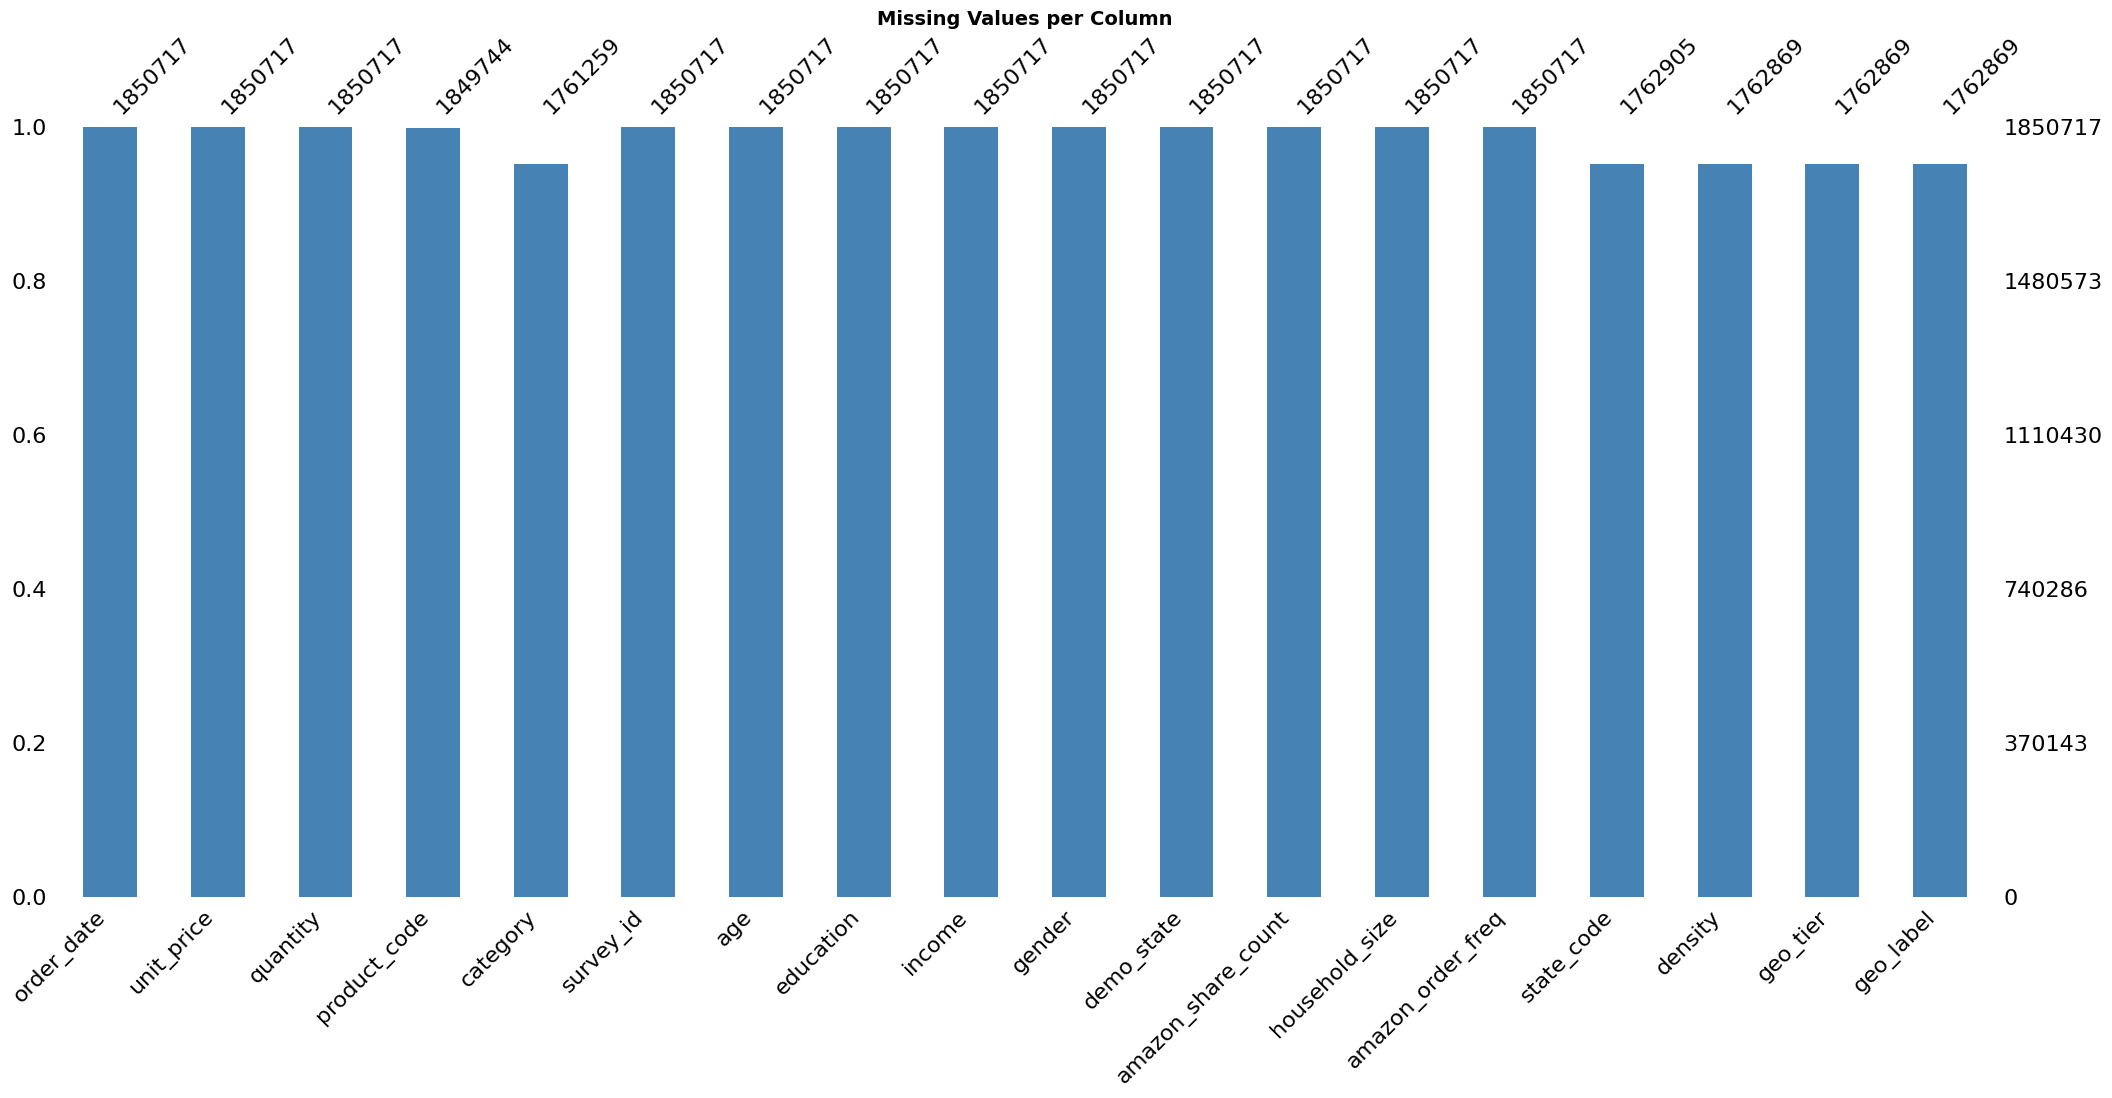

In [18]:
# Missing Data Visualization using missingno
import missingno as msno

# 1. Bar chart of null counts per column
plt.figure(figsize=(12,6))
msno.bar(df, color='steelblue')
plt.title("Missing Values per Column", fontsize=14, weight='bold')
plt.show()


<Figure size 1200x600 with 0 Axes>

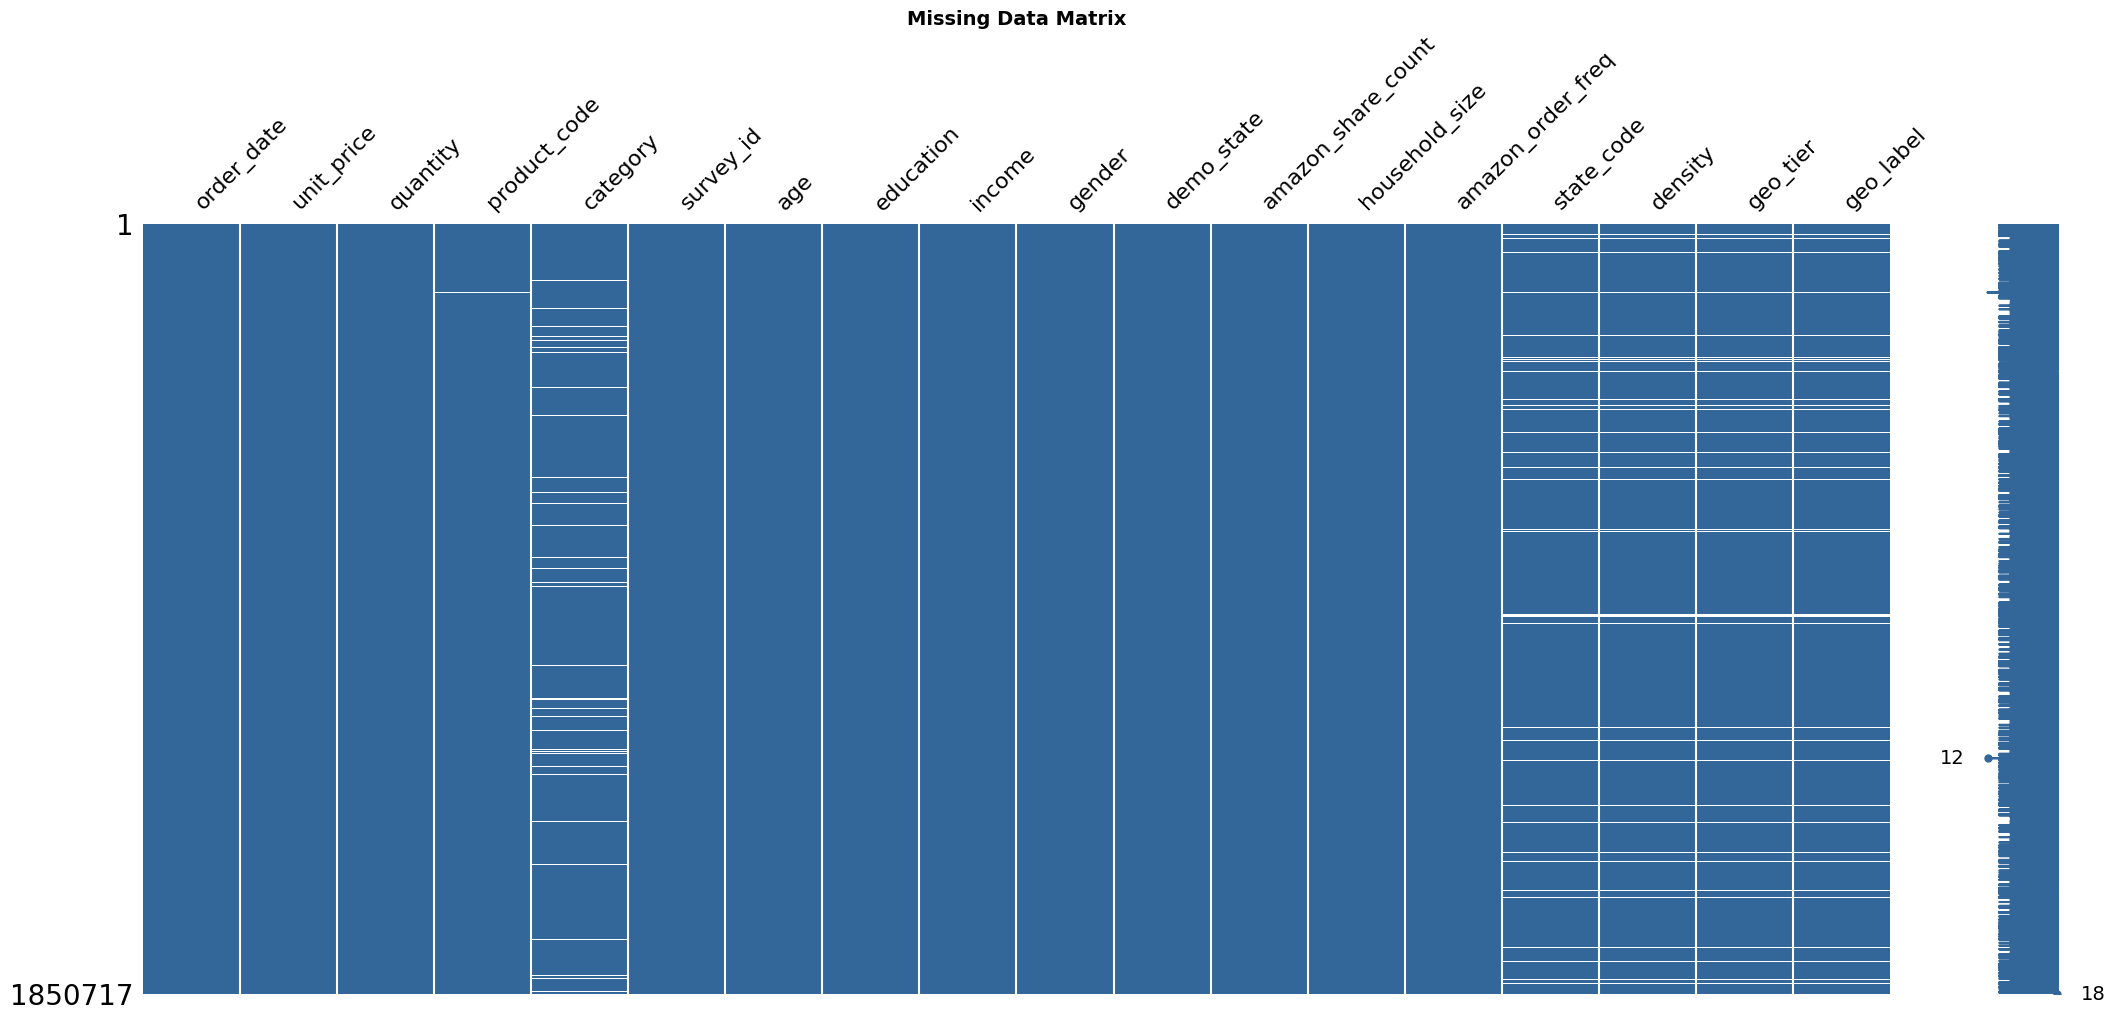

In [19]:
# 2. Matrix plot to see data completeness patterns
plt.figure(figsize=(12,6))
msno.matrix(df, color=(0.2, 0.4, 0.6))
plt.title("Missing Data Matrix", fontsize=14, weight='bold')
plt.show()


<Figure size 1000x600 with 0 Axes>

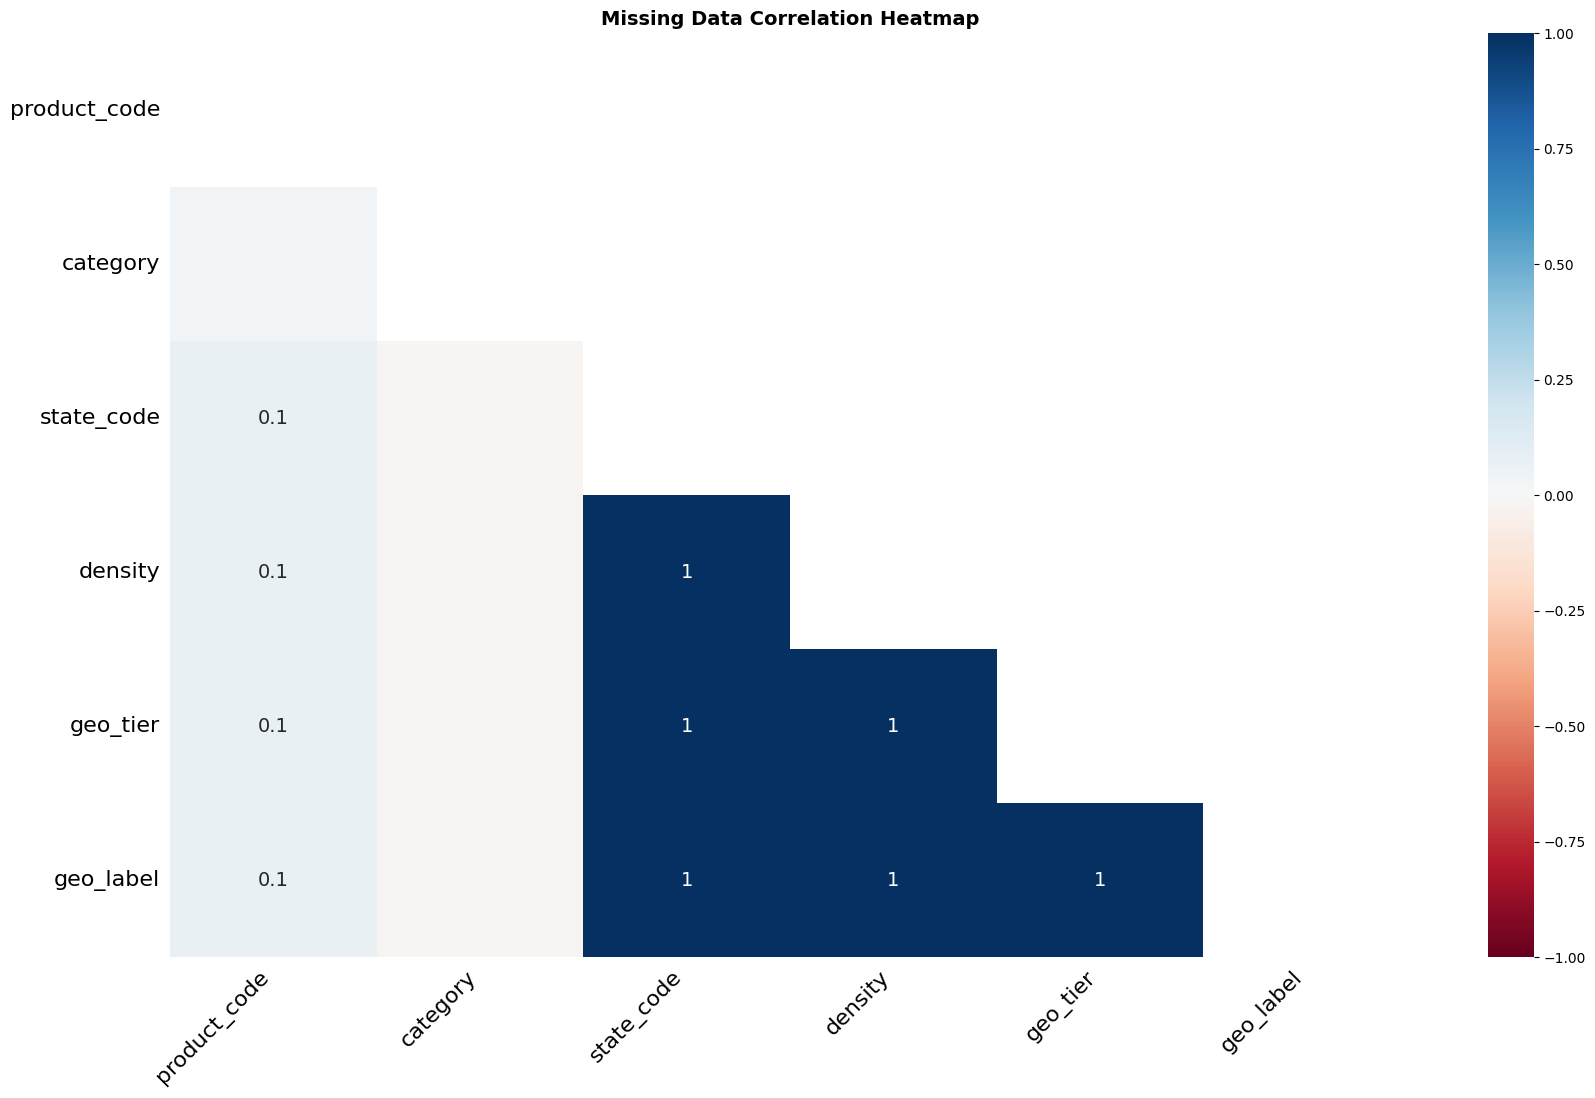

In [20]:
# 3. Heatmap to check correlations of missingness
plt.figure(figsize=(10,6))
msno.heatmap(df)
plt.title("Missing Data Correlation Heatmap", fontsize=14, weight='bold')
plt.show()


### *3. Dealing with Categories inconsitency*

Some survey answers arrived with very wordy text. Things like "1 (just me!)" or "5 minus 10 times per month". On a chart axis, those take up too much space and look messy. I replaced them with shorter versions using a simple dictionary. "1 (just me!)" became just "1". The long education labels became "Bachelor" or "High School". No meaning is lost, but the plots are much cleaner.

In [21]:
# Replace only the specific value in two columns
df['amazon_share_count'] = df['amazon_share_count'].replace("1 (just me!)", "1")
df['household_size'] = df['household_size'].replace("1 (just me!)", "1")

# Use mapping dictionaries for the other three columns
category_mappings = {
    'amazon_order_freq': {
        "5 - 10 times per month": "5-10 per month",
        "Less than 5 times per month": "<5 per month",
        "More than 10 times per month": ">10 per month"
    },
    'education': {
        "Bachelor's degree": "Bachelor",
        "High school diploma or GED": "High School",
        "Graduate or professional degree (MA, MS, MBA, PhD, JD, MD, DDS, etc)": "Graduate/Professional",
        "Prefer not to say": "Prefer not to say",
        "Some high school or less": "Below High School"
    },
    'age': {
        "18 - 24 years": "18-24",
        "25 - 34 years": "25-34",
        "35 - 44 years": "35-44",
        "45 - 54 years": "45-54",
        "55 - 64 years": "55-64",
        "65 and older": "65+"
    }
}

# Apply mappings in a loop for the remaining columns
for col, mapping in category_mappings.items():
    df[col] = df[col].replace(mapping)

# Quick check to confirm changes
for col in ['amazon_share_count','household_size'] + list(category_mappings.keys()):
    print("\n",df[col].value_counts())



 amazon_share_count
1     1005451
2      589514
3      152151
4+     103601
Name: count, dtype: int64

 household_size
2     597375
4+    545226
3     354154
1     353962
Name: count, dtype: int64

 amazon_order_freq
5-10 per month    772882
<5 per month      699677
>10 per month     378158
Name: count, dtype: int64

 education
Bachelor                 830793
High School              593804
Graduate/Professional    402188
Prefer not to say         12191
Below High School         11741
Name: count, dtype: int64

 age
25-34    587589
35-44    569786
45-54    319992
18-24    164251
55-64    153667
65+       55432
Name: count, dtype: int64


### *4. Dealing with "Duplicate" & "Fuzzy" data*

In [22]:
# Exact duplicates across all columns
exact_dups = df.duplicated().sum()

print(f"Exact duplicate rows  : {exact_dups:,}")

Exact duplicate rows  : 11,631


In [23]:
# Show the first 10 exact duplicate rows in full table format
print("Exact duplicate rows:\n")
print(df[df.duplicated()].head(10).to_string())


Exact duplicate rows:

     order_date  unit_price  quantity product_code                 category          survey_id    age    education               income  gender    demo_state amazon_share_count household_size amazon_order_freq state_code  density  geo_tier geo_label
34   2019-10-06       50.00       1.0   B07RTN4C77                GIFT_CARD  R_01vNIayewjIIKMF  35-44     Bachelor    $25,000 - $49,999    Male    New Jersey                  1              1      <5 per month       <NA>      NaN       NaN       NaN
598  2021-01-04      200.00       1.0   B00IX1I3G6                GIFT_CARD  R_037XK72IZBJyF69  55-64     Bachelor    $25,000 - $49,999  Female  Pennsylvania                  1              2      <5 per month       <NA>      NaN       NaN       NaN
689  2021-03-02        5.30       1.0   1539300927                ABIS_BOOK  R_037XK72IZBJyF69  55-64     Bachelor    $25,000 - $49,999  Female  Pennsylvania                  1              2      <5 per month         PA    290

In [24]:
# Define the key columns for duplicate detection
key_cols = ["survey_id", "order_date", "product_code"]

# Flag duplicates based on those keys
df["fuzzy_dup_flag"] = df.duplicated(subset=key_cols, keep=False)

print("Fuzzy duplicates flagged:", df["fuzzy_dup_flag"].sum())


Fuzzy duplicates flagged: 27433


In [25]:
# Collect all fuzzy duplicates
dups = df[df["fuzzy_dup_flag"]]

# Sort so duplicates appear next to each other
dups = dups.sort_values(by=["survey_id", "order_date", "product_code"])

# Show the first few groups in full table format
print(dups.head(20).to_string())


     order_date  unit_price  quantity product_code                 category          survey_id    age    education               income  gender    demo_state amazon_share_count household_size amazon_order_freq state_code  density  geo_tier geo_label  fuzzy_dup_flag
33   2019-10-06       50.00       1.0   B07RTN4C77                GIFT_CARD  R_01vNIayewjIIKMF  35-44     Bachelor    $25,000 - $49,999    Male    New Jersey                  1              1      <5 per month       <NA>      NaN       NaN       NaN            True
34   2019-10-06       50.00       1.0   B07RTN4C77                GIFT_CARD  R_01vNIayewjIIKMF  35-44     Bachelor    $25,000 - $49,999    Male    New Jersey                  1              1      <5 per month       <NA>      NaN       NaN       NaN            True
86   2020-08-28       50.00       1.0   B07RTN4C77                GIFT_CARD  R_01vNIayewjIIKMF  35-44     Bachelor    $25,000 - $49,999    Male    New Jersey                  1              1      <5 pe

### *5. Dealing with outliers*

In [26]:
# Count frequency of Quantity values
quantity_counts = df['quantity'].value_counts().sort_index()

# Restrict to 0–20
quantity_range_counts = quantity_counts.loc[0:30]

# Display as a table
print(quantity_range_counts)


quantity
1.0     1747647
2.0       76838
3.0       13953
4.0        6938
5.0        2211
6.0        1254
7.0         283
8.0         406
9.0          90
10.0        530
11.0         30
12.0        144
13.0         21
14.0         20
15.0         46
16.0         36
17.0         11
18.0         11
19.0          5
20.0         68
21.0         24
22.0          4
23.0          5
24.0         13
25.0         14
26.0          4
27.0          3
28.0          4
29.0          1
30.0         28
Name: count, dtype: int64


In [27]:
df['buyer_segment'] = df['quantity'].apply(lambda x: 'Retail'
                                           if x <= 5
                                           else ('SmallBusiness' if x <= 10 else 'Bulk'))

# Quick check of ranges
df.groupby('buyer_segment')['unit_price'].describe()


,count,mean,std,min,25%,50%,75%,max
buyer_segment,,,,,,,,
Bulk,567.0,10.203686,20.780278,0.09,0.99,3.86,10.670,216.86
Retail,1847587.0,22.679105,46.017048,0.01,8.49,13.99,23.770,6398.95
SmallBusiness,2563.0,10.967331,34.135870,0.08,1.88,5.25,12.955,849.99


In [28]:
import numpy as np

# Define bins from 0 to 3000 in steps of 100
bins = np.arange(0, 6400, 100)

# Create bin labels
labels = [f"{i}-{i+100}" for i in bins[:-1]]

# Group Unit price into bins
df['price_bin'] = pd.cut(df['unit_price'], bins, labels=labels, include_lowest=True)

# Count frequencies by buyer segment and price bin
price_bin_counts = (
    df.groupby(['buyer_segment','price_bin'], observed=True)
      .size()
      .unstack(fill_value=0)
)

print(price_bin_counts.to_string())


price_bin        0-100  100-200  200-300  300-400  400-500  500-600  600-700  700-800  800-900  900-1000  1000-1100  1100-1200  1200-1300  1300-1400  1400-1500  1500-1600  1600-1700  1700-1800  1800-1900  1900-2000  2000-2100  2100-2200  2200-2300  2300-2400  2400-2500  2500-2600  2600-2700  2700-2800  2800-2900  2900-3000  3200-3300  3400-3500  3500-3600  3700-3800  4200-4300  4900-5000  5400-5500  5900-6000
buyer_segment                                                                                                                                                                                                                                                                                                                                                                                                               
Bulk               562        4        1        0        0        0        0        0        0         0          0          0          0          0          0          0    

In [29]:
def segment_outlier(row):
    if row['buyer_segment'] == 'Retail':
        return 'Normal' if row['unit_price'] <= 200 else 'Outlier'
    elif row['buyer_segment'] == 'SmallBusiness':
        return 'Normal' if row['unit_price'] <= 200 else 'Outlier'
    else:  # Bulk
        return 'Normal' if row['unit_price'] <= 100 else 'Outlier'

df['outlier_flag'] = df.apply(segment_outlier, axis=1)


In [30]:
summary = df.groupby(['buyer_segment','outlier_flag'])['unit_price'].describe()
print(summary.to_string())


                                count        mean         std     min       25%      50%     75%      max
buyer_segment outlier_flag                                                                               
Bulk          Normal            562.0    8.839217   14.551699    0.09    0.9825    3.790   10.22   100.00
              Outlier             5.0  163.570000   41.727674  125.00  136.9900  139.000  200.00   216.86
Retail        Normal        1834207.0   19.960428   22.080839    0.01    8.4000   13.990   22.99   200.00
              Outlier         13380.0  395.370820  292.680635  200.02  249.9500  299.990  409.99  6398.95
SmallBusiness Normal           2557.0    9.524810   13.655467    0.08    1.8800    5.190   12.94   200.00
              Outlier             6.0  625.721667  217.214179  250.00  545.7500  697.175  747.83   849.99


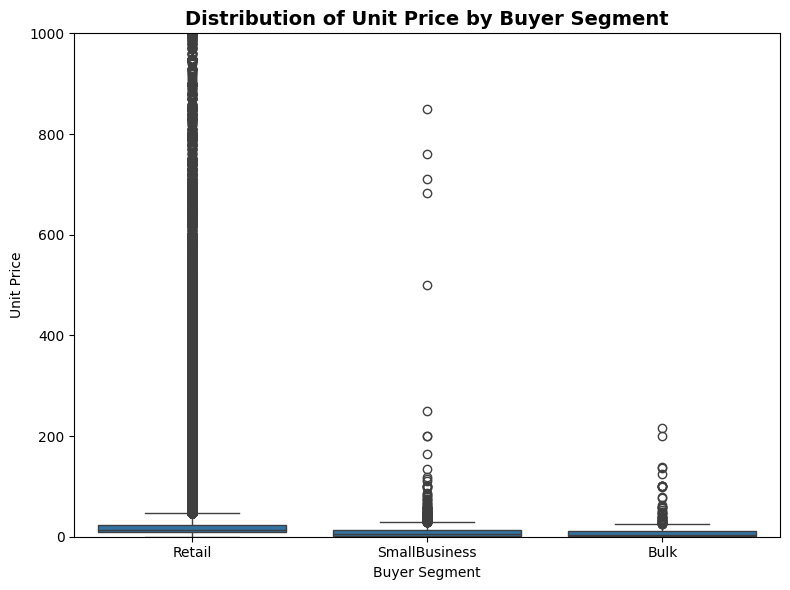

In [31]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x='buyer_segment', y='unit_price', data=df)
plt.title("Distribution of Unit Price by Buyer Segment", fontsize=14, fontweight='bold')
plt.ylabel("Unit Price")
plt.xlabel("Buyer Segment")
plt.ylim(0, 1000)  # focus on main range, exclude extreme outliers
plt.tight_layout()
plt.show()


In [32]:
df.columns

Index(['order_date', 'unit_price', 'quantity', 'product_code', 'category',
       'survey_id', 'age', 'education', 'income', 'gender', 'demo_state',
       'amazon_share_count', 'household_size', 'amazon_order_freq',
       'state_code', 'density', 'geo_tier', 'geo_label', 'fuzzy_dup_flag',
       'buyer_segment', 'price_bin', 'outlier_flag'],
      dtype='object')

#### ***Notes:***
I did not throw away extreme prices or quantities. Instead, I used the quantity column to build a new feature called buyer segment. Orders with five or fewer units are labelled Retail.

 Six to ten units are Small Business. More than ten are Bulk. Then within each segment, I set sensible price thresholds to flag something as an outlier.

 For example, over two hundred dollars is unusual for a single retail item. The outliers are only flagged, not removed. This way the raw data stays intact, and I can do my analysis with or without those flagged rows depending on what I need.

## C | **FEATURE ENGINEERING**

### *1. Time feature*

I pulled the year, month, and weekday out of the order date. These are simple but essential. They let me look at whether repeat buying changes by season or by day of the week. I was especially curious about the holiday months, because any e‑commerce person will tell you that customer behaviour shifts in November and December.

In [33]:
# Extract components
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["order_weekday"] = df["order_date"].dt.day_name()


### *2. Price features*

I already had unit price and quantity, but I wanted a single number that captures the total spend on an order. So I multiplied them together to get total order value. This lets me compare spending power across different customer segments later.

I also created a price band column. Unit price is a continuous number, but continuous data is hard to group neatly for bar charts and chi‑square tests. By cutting price into four equal sized bins and labelling them Low, Mid, High, and Premium, I turned a messy continuous variable into a clean categorical one. This makes it easy to ask a simple question: do cheap items get rebought more often than expensive ones?

In [34]:
#
df['log_price'] = np.log1p(df['unit_price'])
df["total_value"] = df["unit_price"] * df["quantity"]
df["price_bin"] = pd.qcut(df["unit_price"], q=4, labels=["Low","Mid","High","Premium"])

### *3. Repeat behaviour features*

This is where the core of the analysis lives. I needed a clear way to mark whether a customer bought the same product more than once. So I created a flag column, repeat same product flag. It checks if a customer has ever purchased that exact product before. The result is a simple binary column, one for repeat, zero for first time. Binary format is perfect because it becomes the target variable in both my chi‑square tests and the logistic regression later.

I also created repeat gap days to measure the time between two consecutive purchases of the same product by the same customer. This one needed extra care. If I did the grouping wrong or sorted the dates badly, I could end up with negative day gaps, which would be nonsense. So I sorted the data by customer, product, and date first, then used a proper groupby difference. This column became the backbone of my test on whether rural customers take longer to come back than urban ones.

In [35]:
#
df['repeat_same_product_flag'] = df.duplicated(subset=['survey_id','product_code'], keep = False).astype(int)

df = df.sort_values(["survey_id","product_code","order_date"])
df["repeat_gap_days"] = (df.groupby(["survey_id","product_code"])["order_date"].diff().dt.days)

In [36]:
df_neg = df[df["repeat_gap_days"] < 0].head(20)

# Correct usage
print(df_neg.to_string())


Empty DataFrame
Columns: [order_date, unit_price, quantity, product_code, category, survey_id, age, education, income, gender, demo_state, amazon_share_count, household_size, amazon_order_freq, state_code, density, geo_tier, geo_label, fuzzy_dup_flag, buyer_segment, price_bin, outlier_flag, order_year, order_month, order_weekday, log_price, total_value, repeat_same_product_flag, repeat_gap_days]
Index: []


In [37]:
df_sorted = df.sort_values(by=["survey_id","order_date"])
df_check = df_sorted[["survey_id","order_date","product_code","repeat_gap_days"]]
print(df_check.head(10).to_string())

           survey_id order_date product_code  repeat_gap_days
0  R_01vNIayewjIIKMF 2018-12-04   B0143RTB1E              NaN
1  R_01vNIayewjIIKMF 2018-12-22   B01MA1MJ6H              NaN
2  R_01vNIayewjIIKMF 2018-12-24   B078JZTFN3              NaN
4  R_01vNIayewjIIKMF 2018-12-25   B00837ZOI0              NaN
3  R_01vNIayewjIIKMF 2018-12-25   B06XWF9HML              NaN
6  R_01vNIayewjIIKMF 2019-02-18   B00NH13S44              NaN
5  R_01vNIayewjIIKMF 2019-02-18   B01GFB2E9M              NaN
7  R_01vNIayewjIIKMF 2019-03-15   B077H6L7T9              NaN
9  R_01vNIayewjIIKMF 2019-04-23   B06XKNWJN2              NaN
8  R_01vNIayewjIIKMF 2019-04-23   B07L84ZZXC              NaN


In [38]:
df["repeat_gap_days"] = df["repeat_gap_days"].fillna(0)

In [39]:
pd.options.display.float_format = '{:.2f}'.format
df["repeat_gap_days"].describe()

,repeat_gap_days
count,1850717.00
mean,19.62
std,87.52
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,1870.00


In [40]:
# Define 20 segments: 0.05, 0.10, ... 1.00
percentiles = [i/20 for i in range(1, 21)]

# Compute them
gap_percentiles = df["repeat_gap_days"].quantile(percentiles)

print(gap_percentiles)

0.05      0.00
0.10      0.00
0.15      0.00
0.20      0.00
0.25      0.00
0.30      0.00
0.35      0.00
0.40      0.00
0.45      0.00
0.50      0.00
0.55      0.00
0.60      0.00
0.65      0.00
0.70      0.00
0.75      0.00
0.80      0.00
0.85      1.00
0.90     31.00
0.95    105.00
1.00   1870.00
Name: repeat_gap_days, dtype: float64


## D | **EXPLORATORY DATA ANALYSIS**

**In this section,** I first check basic distributions, normality, and missing patterns. Then I look at repeat purchase rate across income, category, price band, buyer segment, and month. After that, I dig deeper into geography to see how urban, suburban, and rural groups differ in spending, product choice, and repeat behavior.

I do this ***before hypothesis testing*** because EDA helps me understand the shape of the data first. It also helps me choose the right statistical tests later.

In [42]:
# --- helper plots ---
def numeric_dist(series, title):
    # Plot distribution of a numeric column.
    # Why: lets us quickly see spread, skew, and outliers.
    # Histogram + KDE shows overall shape; boxplot highlights extreme values.

    x = series.dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(x, kde=True, ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 2.5))
    sns.boxplot(x=x, ax=ax)
    ax.set_title(f"{title} - Box Plot")
    plt.tight_layout()
    plt.show()

def binary_rate_bar(data, x, y="repeat_same_product_flag", title=""):
    # Bar plot of repeat purchase rate by a categorical variable.
    # Why: shows how repeat behavior differs across groups (e.g., category, state).

    plt.figure(figsize=(9, 4))
    sns.barplot(data=data, x=x, y=y, estimator=np.mean, errorbar=None)
    plt.title(title)
    plt.ylabel("Repeat rate")
    plt.xlabel(x)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

def normality_audit(series, sample_size=5000):
    # Run normality tests (Shapiro, D’Agostino) on a sample.
    # Why: check if numeric data is close to normal distribution
    # before applying parametric tests or transformations.

    x = series.dropna()
    if len(x) > sample_size:
        x = x.sample(sample_size, random_state=42)

    out = {"n": len(x)}
    if len(x) >= 3:
        out["shapiro_p"] = stats.shapiro(x).pvalue
    else:
        out["shapiro_p"] = np.nan
    if len(x) >= 8:
        out["normaltest_p"] = stats.normaltest(x).pvalue
    else:
        out["normaltest_p"] = np.nan
    return out

def qq_plot(series, title):
    # QQ plot against normal distribution.
    # Why: visual check for normality — points should align with diagonal if data is normal.

    x = series.dropna()
    plt.figure(figsize=(6, 6))
    stats.probplot(x, dist="norm", plot=plt)
    plt.title(title)
    plt.tight_layout()
    plt.show()

### *0. Data Health check*

category        89458
geo_tier        87848
density         87848
geo_label       87848
state_code      87812
product_code      973
dtype: int64
Duplicate rows: 8914
Customers: 5027
Products: 939082
Categories: 1871
States: 52


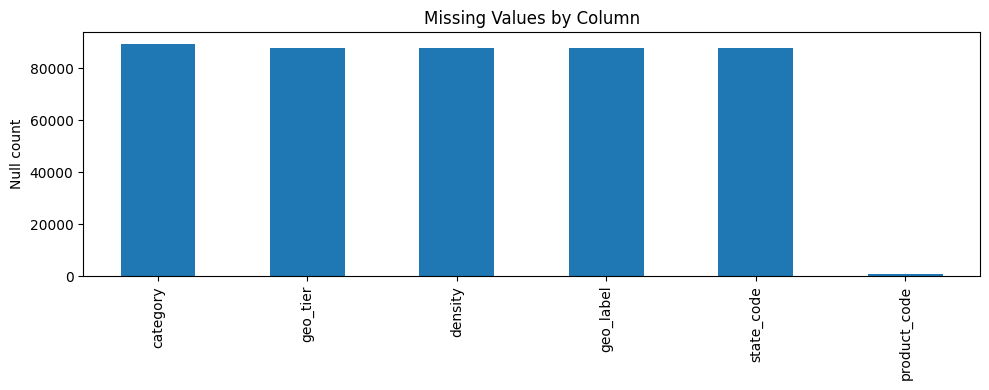

In [43]:
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

print("Duplicate rows:", df.duplicated().sum())
print("Customers:", df["survey_id"].nunique())
print("Products:", df["product_code"].nunique())
print("Categories:", df["category"].nunique())
print("States:", df["state_code"].nunique())

plt.figure(figsize=(10, 4))
missing[missing > 0].plot(kind="bar")
plt.title("Missing Values by Column")
plt.ylabel("Null count")
plt.tight_layout()
plt.show()

***Note:***

The first thing I checked was the quality of the merged dataset. The product-related columns were almost complete, with only a negligible number of missing values. Most of the missing values came from survey-related fields, especially personal demographic questions where many users skipped answers.

One important thing I noticed was that around **90k+** rows had missing values in some survey columns, but this does not mean the orders are useless. The actual transaction data is still present, so deleting those rows would throw away a huge amount of valid buying behavior.

I also found:
* around **11k** exact duplicate rows
* around **27k** fuzzy duplicates

At first, duplicates may look like a data error, but in e commerce this is not always true. A customer can buy the same item multiple times on the same day, especially for bulk orders, subscriptions, gift cards, or business purchases. Because of that, I did not blindly delete every duplicate row. Instead, I flagged and studied them carefully before deciding what to keep. That keeps the dataset realistic instead of "over-cleaned".

### *1. Distribution Audit*

Before any testing, I need to see the shape of the numeric columns. Histograms and density plots tell me whether the data is spread out, clumped, or skewed. That guides everything later.

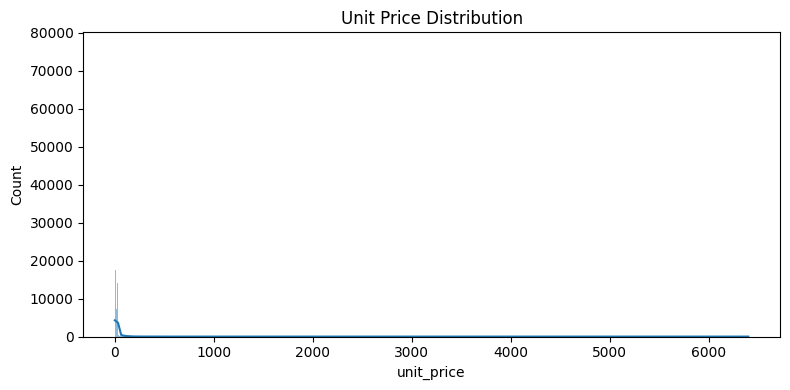

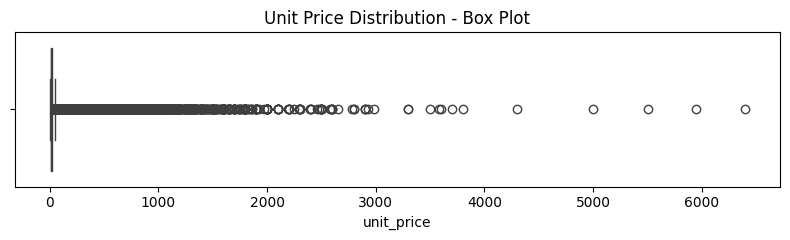

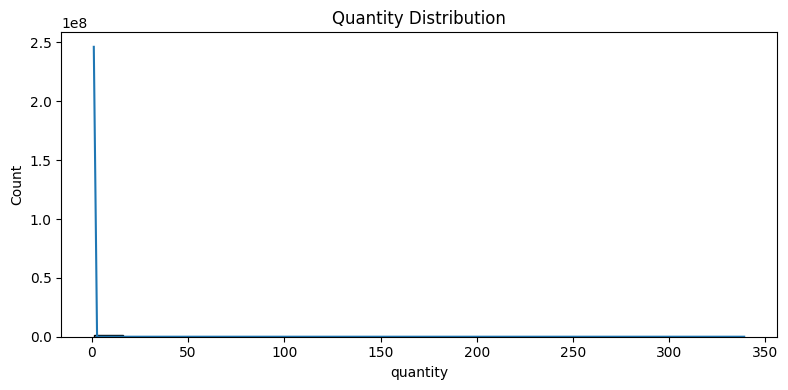

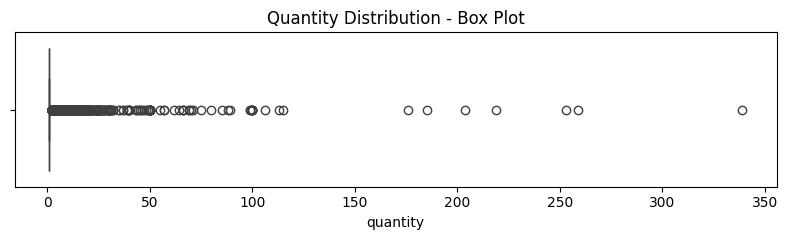

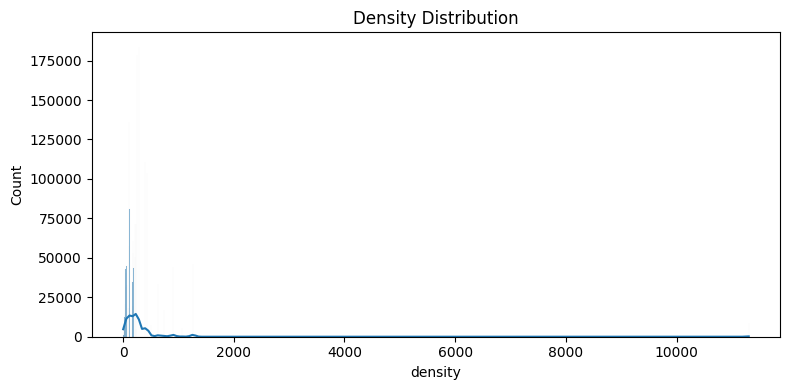

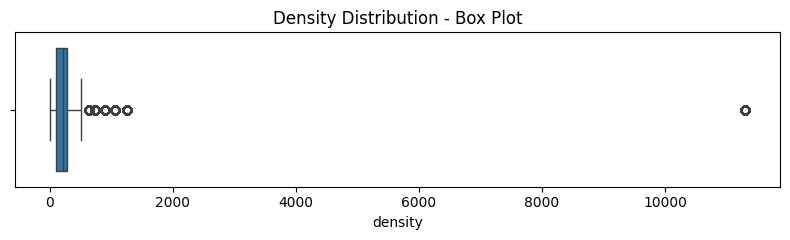

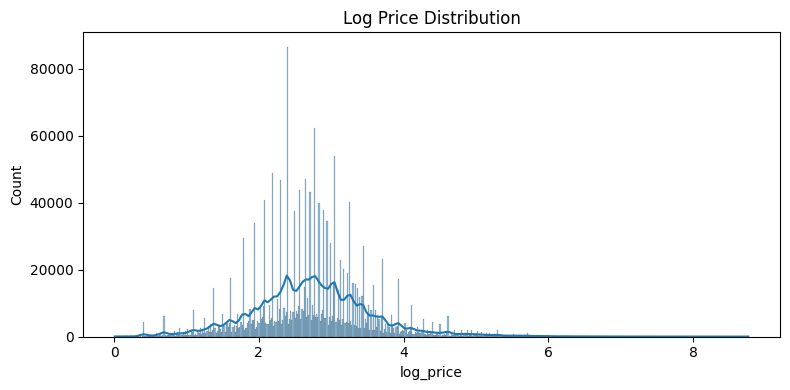

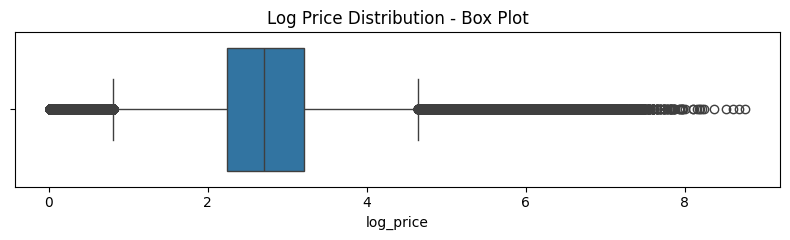

In [44]:
numeric_dist(df["unit_price"], "Unit Price Distribution")
numeric_dist(df["quantity"], "Quantity Distribution")
numeric_dist(df["density"], "Density Distribution")
numeric_dist(df["log_price"], "Log Price Distribution")

***Note:***

The unit price histogram tells one story, while the box plot tells another.

The histogram shows that most products are concentrated in the lower price range, mainly between 0 and 100 dollars, which is expected in Amazon-style marketplaces because low-cost items move faster and in larger quantities.

But the box plot reveals something important:
there are a huge number of extreme outliers stretching far above the normal range. That means a small number of very expensive products are pulling the average upward.

So even though the histogram looks manageable, the box plot tells us the raw price data is heavily skewed.

This is why I created and used log-transformed price features later. Log price compresses the extreme values and makes the distribution easier to compare without deleting expensive products from the dataset.

In simple words:

* the histogram shows where most products live
* the box plot shows how extreme the market really is

### *2. Normality check & selection*

unit_price: {'n': 5000, 'shapiro_p': np.float64(1.0909504509968398e-85), 'normaltest_p': np.float64(0.0)}
quantity: {'n': 5000, 'shapiro_p': np.float64(5.1677482441942135e-93), 'normaltest_p': np.float64(0.0)}
density: {'n': 5000, 'shapiro_p': np.float64(1.964735641183897e-90), 'normaltest_p': np.float64(0.0)}
log_price: {'n': 5000, 'shapiro_p': np.float64(1.123879804444187e-24), 'normaltest_p': np.float64(5.5503520177131574e-61)}


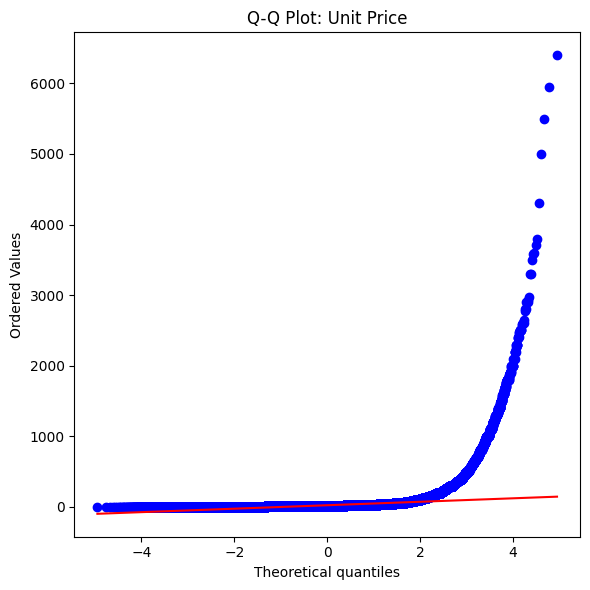

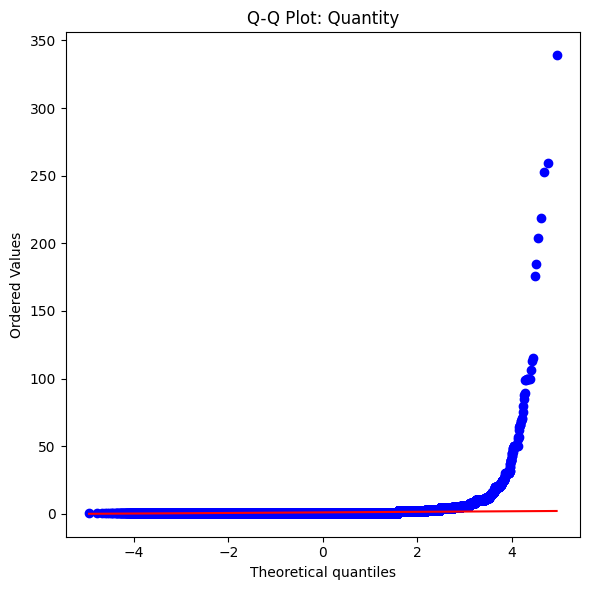

In [45]:
print("unit_price:", normality_audit(df["unit_price"]))
print("quantity:", normality_audit(df["quantity"]))
print("density:", normality_audit(df["density"]))
print("log_price:", normality_audit(df["log_price"]))

qq_plot(df["unit_price"], "Q-Q Plot: Unit Price")
qq_plot(df["quantity"], "Q-Q Plot: Quantity")

***Note:***

Before choosing statistical tests, I checked whether the numeric variables followed a normal distribution.

I used:
* histograms
* Q-Q plots
* skewness checks
* formal normality testing

The result was very clear:
the data is not normally distributed.

The repeat-gap variable especially had a huge spike near zero and a very long right tail. Price-related variables were also strongly skewed.

Because of this, using methods that assume "perfect bell-curve data" would not be reliable here.

### *3. Distribution of repeat flags*

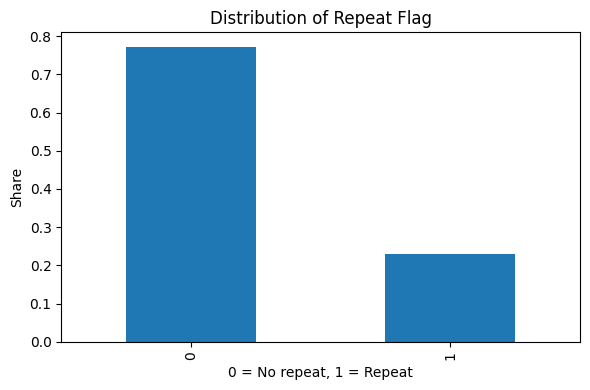

In [46]:
plt.figure(figsize=(6, 4))
df["repeat_same_product_flag"].value_counts(normalize=True).sort_index().plot(kind="bar")
plt.title("Distribution of Repeat Flag")
plt.xlabel("0 = No repeat, 1 = Repeat")
plt.ylabel("Share")
plt.tight_layout()
plt.show()

***Note:***

One thing immediately stands out in this chart:
there is a very large spike in non-repeat purchases.That actually makes sense in e commerce. Many Amazon purchases are naturally one-time decisions.

### *4. Distribution of repeat gap days*

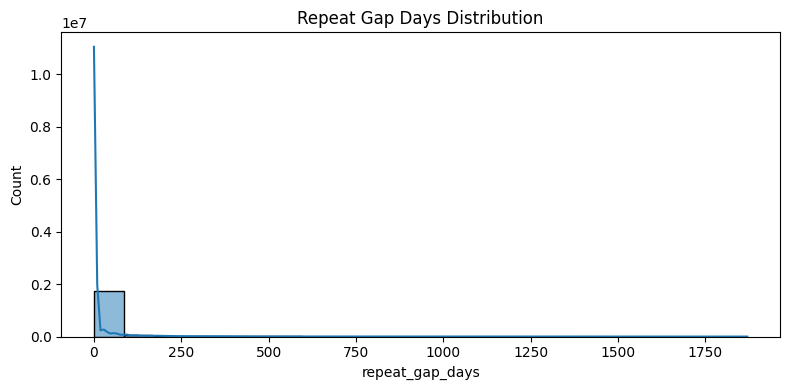

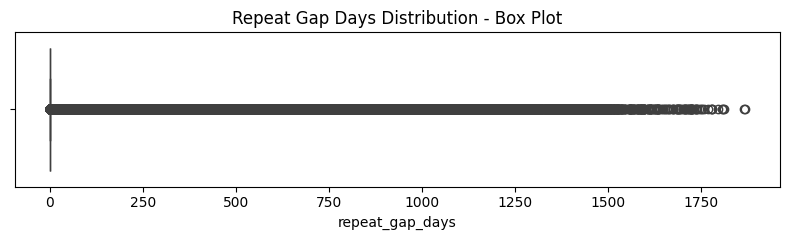

In [47]:
numeric_dist(df["repeat_gap_days"], "Repeat Gap Days Distribution")

***Note:***

After I corrected the negative values of the repeat days, it showed a dense cluster between zero and about two hundred fifty days.The histogram and the box plot again tell slightly different stories.

The histogram shows that most repeat purchases happen very quickly, with a heavy concentration near zero days.

But the box plot shows a long tail extending very far outward. That means a smaller group of customers waits weeks or even months before repeating the same purchase.

This creates an interesting story:

* routine products repeat quickly
* occasional products repeat slowly
* some products may only repeat during events or seasons

The median being near zero tells us fast repeat behavior dominates the dataset.

### *5. Repeat rate by geo tier*

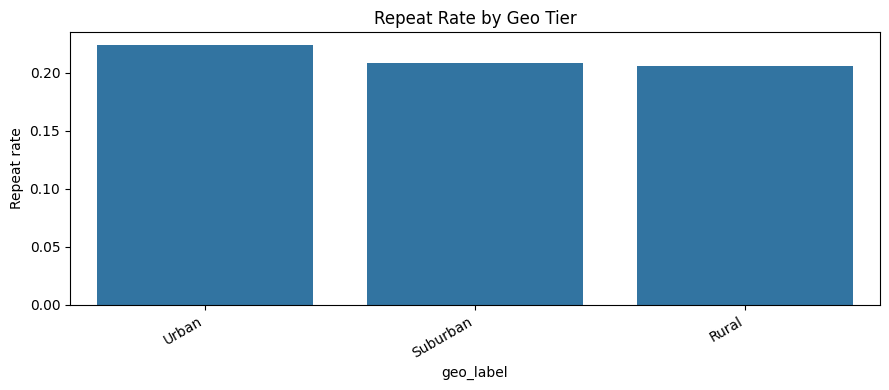

In [48]:
binary_rate_bar(df.dropna(subset=["geo_label"]), "geo_label", title="Repeat Rate by Geo Tier")

***Note:***

At first glance, rural, suburban, and urban repeat rates look surprisingly similar.

I expected larger differences before seeing the chart.

My assumption is that Amazon’s platform standardizes the shopping experience enough that geography alone cannot completely change repeat-buying behavior anymore. Delivery networks, Prime membership, and nationwide product access may reduce the old “rural disadvantage” effect that people usually assume exists.

So geography may matter a little, but not dramatically.

### *6. Repeat rate by income*

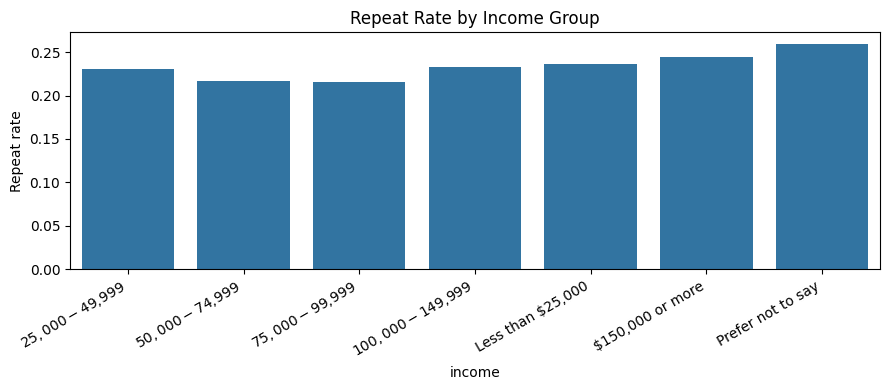

In [49]:
binary_rate_bar(df.dropna(subset=["income"]), "income", title="Repeat Rate by Income Group")

***Note:***

The income chart shows something interesting.

Lower-income groups generally have slightly lower repeat rates, while higher-income groups show slightly higher repeat behavior. But the difference is still not huge.

One strange thing is the “Prefer not to answer” category. I personally suspect some small business owners or high-frequency buyers may avoid sharing income details in surveys. That is only an assumption, not a proven fact, but it could explain why that group behaves differently from expected.

Overall, income seems connected to repeat purchases, but not strongly enough to fully explain customer loyalty.

### *7. Repeat rate by category*

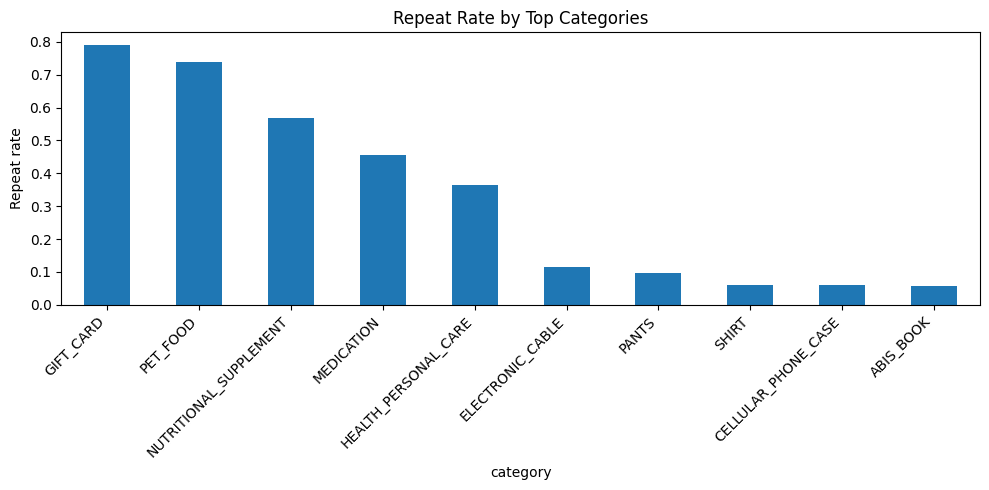

In [50]:
top_cat = df["category"].value_counts().head(10).index
cat_df = df[df["category"].isin(top_cat)].copy()

plt.figure(figsize=(10, 5))
cat_df.groupby("category")["repeat_same_product_flag"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Repeat Rate by Top Categories")
plt.ylabel("Repeat rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

***Note:***

This is where the project becomes much more interesting.

Gift cards, pet products, and pharmacy-related products show some of the highest repeat rates.

That actually makes practical sense:

* pet food is a recurring need
* pharmacy items are routine purchases
* gift cards are often reused for birthdays, holidays, gaming, and digital spending

Another possible reason is convenience. Online marketplaces often offer a larger variety of gift cards and specialty products than local stores, so customers may repeatedly return to the same platform instead of searching elsewhere.

This chart strongly suggests that what people buy matters more than where they live.

### *8. Repeat rate by price band*

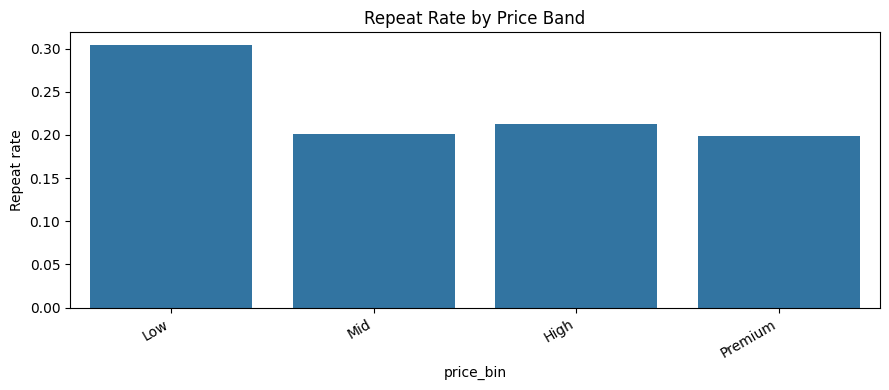

In [51]:
binary_rate_bar(df.dropna(subset=["price_bin"]), "price_bin", title="Repeat Rate by Price Band")

***Note:***

The price-band chart adds another layer to the story.

High-repeat products are often concentrated in lower and medium price bands because routine purchases are usually affordable items.

Expensive products behave differently:
people rarely buy televisions, laptops, or furniture repeatedly within a short time.

So the chart supports a very common e commerce pattern:

* low-cost consumables repeat often
* high-cost durable products repeat rarely

This is one reason why category and price are connected in the repeat-purchase story.


### *9. Repeat rate by buyer segment*

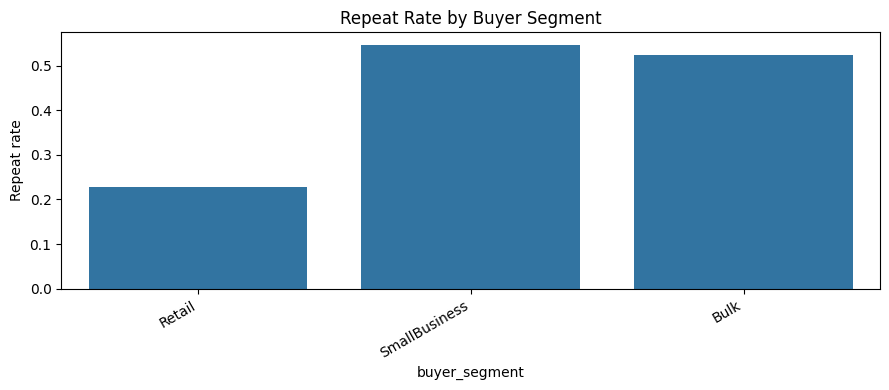

In [52]:
binary_rate_bar(df.dropna(subset=["buyer_segment"]), "buyer_segment", title="Repeat Rate by Buyer Segment")

***Note:***

Retail buyers showed lower repeat rates compared to business or bulk-oriented buyers.

One possible explanation is simple:
retail shoppers are usually casual buyers. They come for specific needs, seasonal shopping, or impulse purchases.

Business buyers behave differently because they often reorder:

* supplies
* inventory
* consumables
* operational products

This pattern is commonly discussed in retail and marketplace reports, especially in studies about subscription-style purchasing and replenishment behavior.

### *10. Time trend per month*

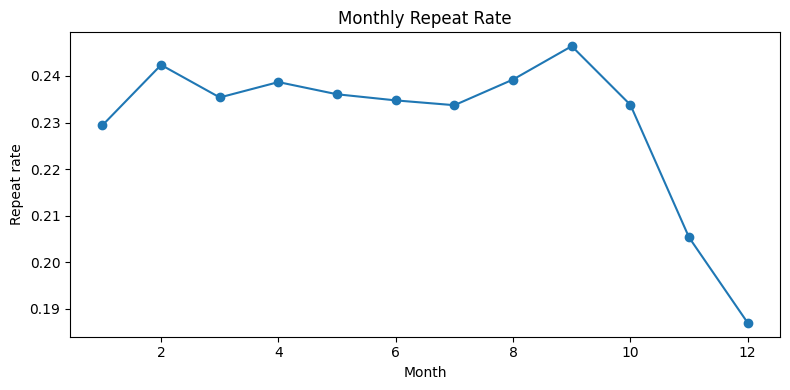

In [53]:
month_rate = df.groupby("order_month")["repeat_same_product_flag"].mean()

plt.figure(figsize=(8, 4))
month_rate.plot(marker="o")
plt.title("Monthly Repeat Rate")
plt.xlabel("Month")
plt.ylabel("Repeat rate")
plt.tight_layout()
plt.show()

***Note:***

The monthly trend suggests a seasonal effect.

Repeat rates become less stable near the last quarter of the year, especially around November and December.

My assumption is that holiday shopping changes customer behavior:
people buy more new products, gifts, decorations, and one-time items instead of repeating old purchases.

January and February also show unstable movement. That may be connected to:

* post-holiday spending slowdowns
* New Year resets
* Valentine’s season purchasing behavior

So seasonality seems real, even though it is not the strongest factor overall.

### *D1 - Geographic Population Profile*

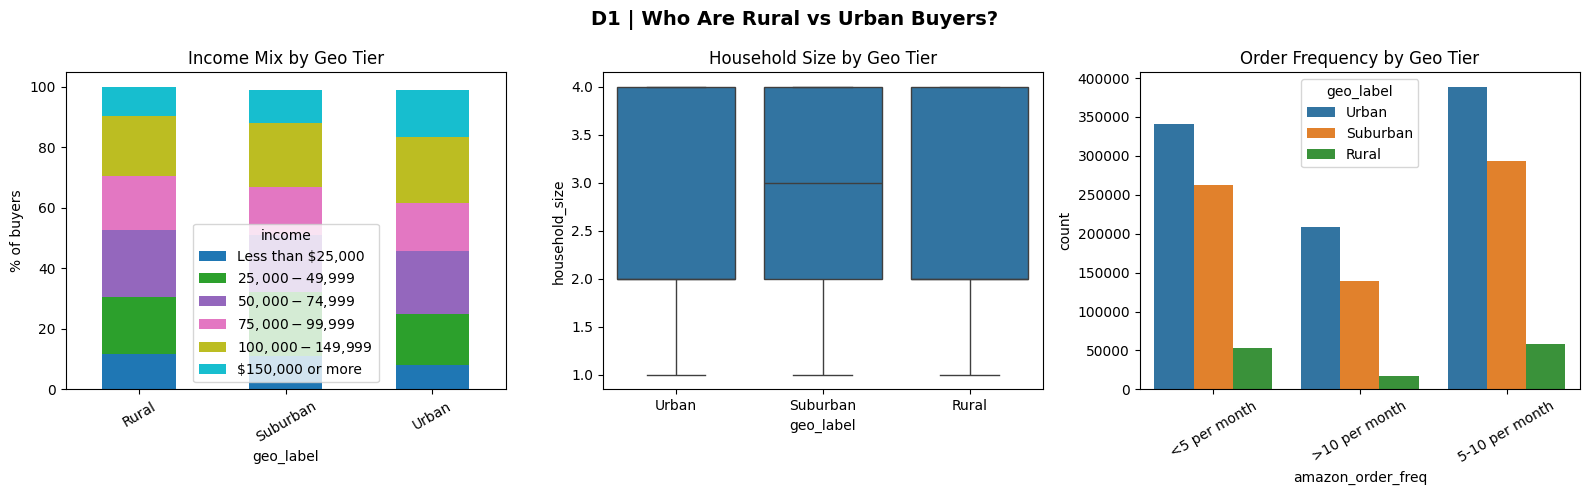

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Income distribution by geo tier
income_order = ["Less than $25,000","$25,000 - $49,999","$50,000 - $74,999",
                "$75,000 - $99,999","$100,000 - $149,999","$150,000 or more"]
income_pct = (df.dropna(subset=["income","geo_label"])
               .groupby(["geo_label","income"])
               .size()
               .unstack(fill_value=0)
               .apply(lambda x: x/x.sum()*100, axis=1))
income_pct[income_order].plot(kind="bar", stacked=True, ax=axes[0], colormap="tab10")
axes[0].set_title("Income Mix by Geo Tier")
axes[0].set_ylabel("% of buyers")
axes[0].tick_params(axis='x', rotation=30)

# Household size by geo tier
df["household_size"] = df["household_size"].replace("4+", "4")
sns.boxplot(data=df.dropna(subset=["household_size","geo_label"]),
            x="geo_label", y=df["household_size"].astype(float),
            ax=axes[1])
axes[1].set_title("Household Size by Geo Tier")

# Order frequency by geo tier
sns.countplot(data=df.dropna(subset=["amazon_order_freq","geo_label"]),
              x="amazon_order_freq", hue="geo_label", ax=axes[2])
axes[2].set_title("Order Frequency by Geo Tier")
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle("D1 | Who Are Rural vs Urban Buyers?", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

***Note:***

The geo-tier profiles do not show massive differences between groups.

That is actually interesting because it suggests online shopping behavior may be becoming more standardized across regions. Rural and urban customers still differ a little in income and household structure, but the gap is not as dramatic as many people expect.

### *D2 - Spending Profile by Geo Tier*

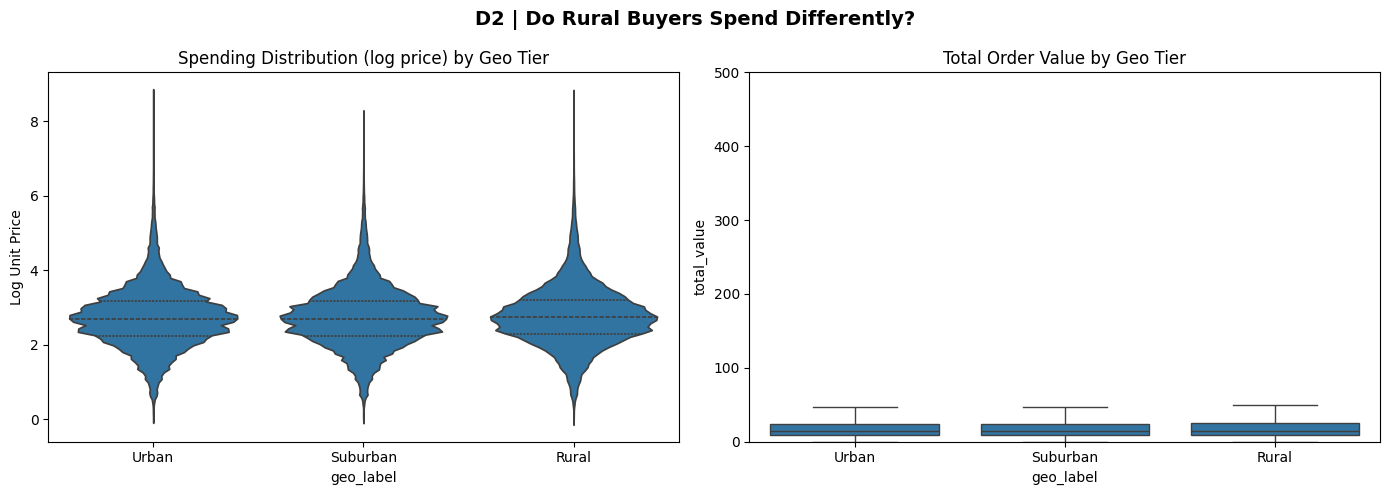

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Unit price distribution by geo tier — violin shows full shape
sns.violinplot(data=df.dropna(subset=["geo_label"]),
               x="geo_label", y="log_price",
               inner="quartile", ax=axes[0])
axes[0].set_title("Spending Distribution (log price) by Geo Tier")
axes[0].set_ylabel("Log Unit Price")

# Total order value (unit_price × qty) by geo tier
sns.boxplot(data=df.dropna(subset=["geo_label"]),
            x="geo_label", y="total_value",
            ax=axes[1], showfliers=False)
axes[1].set_title("Total Order Value by Geo Tier")
axes[1].set_ylim(0, 500)

plt.suptitle("D2 | Do Rural Buyers Spend Differently?", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

***Note:***

Urban spending is slightly higher, but suburban buyers are surprisingly competitive.

One possible explanation is that suburban households often have stable middle-to-upper income lifestyles with strong online purchasing habits. Rural spending is slightly lower overall, but not dramatically separated from the other groups.

Again, the gap exists, but it is smaller than expected.

### *D3 - Category Preferences by Geo Tiers*

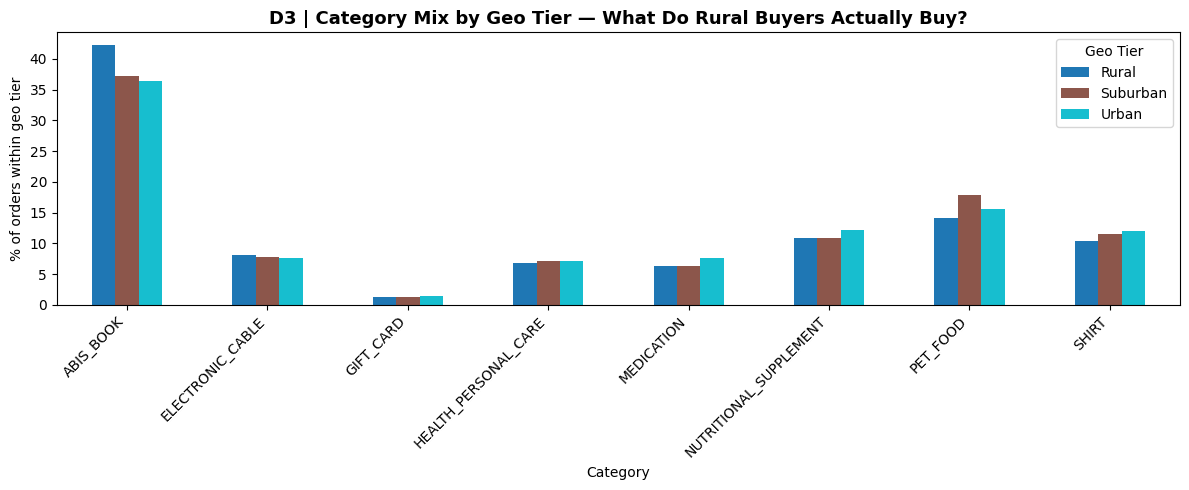

In [56]:
top_cats = df["category"].value_counts().head(8).index
cat_geo = (df[df["category"].isin(top_cats)]
           .dropna(subset=["geo_label"])
           .groupby(["geo_label","category"])
           .size()
           .unstack(fill_value=0)
           .apply(lambda x: x/x.sum()*100, axis=1))

cat_geo.T.plot(kind="bar", figsize=(12, 5), colormap="tab10")
plt.title("D3 | Category Mix by Geo Tier — What Do Rural Buyers Actually Buy?",
          fontsize=13, fontweight='bold')
plt.ylabel("% of orders within geo tier")
plt.xlabel("Category")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Geo Tier")
plt.tight_layout()
plt.show()

***Note:***

Some product categories change depending on the region. For example, books and media are bought differently across areas, which may be linked to hobbies, education, or local store access. Pet products stay steady everywhere because owning pets is common in both cities and rural places.

The key point is that even if a category does not have a very large share of buyers in a region, its repeat rate can still be high if the product is part of a daily routine or habit. In other words, routine items get rebought often no matter where people live.

### *D4 - Repeat Behavior Deep Dive by Geo Tier*

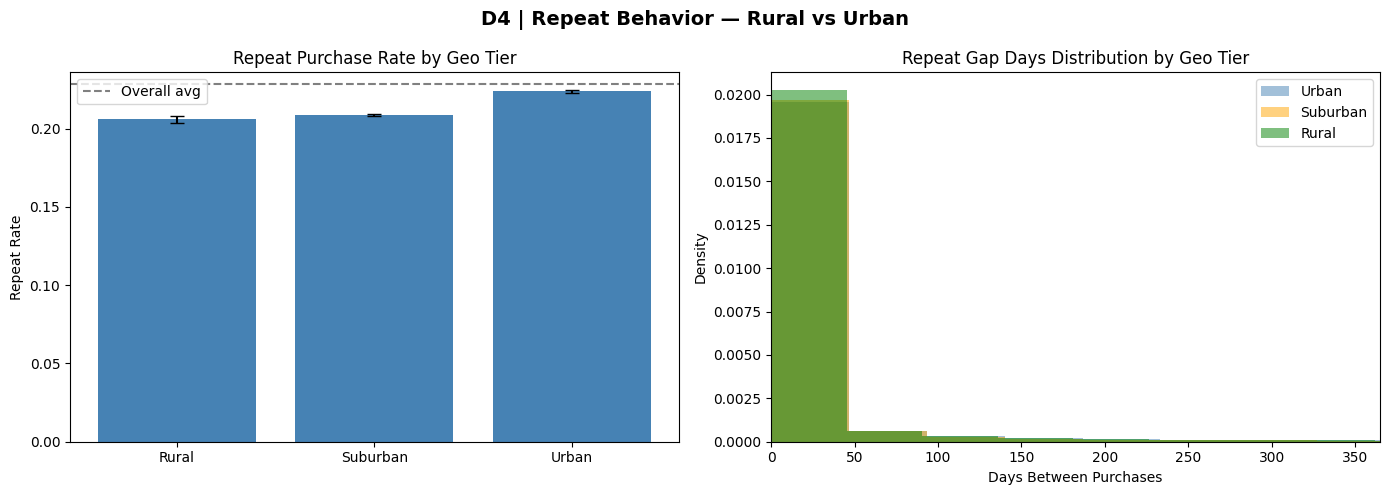

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Repeat flag rate by geo tier (replaces Section 3)
repeat_by_geo = (df.dropna(subset=["geo_label","repeat_same_product_flag"])
                  .groupby("geo_label")["repeat_same_product_flag"]
                  .agg(["mean","count"])
                  .rename(columns={"mean":"repeat_rate","count":"n"}))
repeat_by_geo["ci"] = 1.96 * np.sqrt(
    repeat_by_geo["repeat_rate"] * (1 - repeat_by_geo["repeat_rate"]) / repeat_by_geo["n"])

axes[0].bar(repeat_by_geo.index, repeat_by_geo["repeat_rate"],
            yerr=repeat_by_geo["ci"], capsize=5, color="steelblue")
axes[0].axhline(df["repeat_same_product_flag"].mean(), linestyle="--",
                color="grey", label="Overall avg")
axes[0].set_title("Repeat Purchase Rate by Geo Tier")
axes[0].set_ylabel("Repeat Rate")
axes[0].legend()

# Repeat gap days by geo tier (replaces Section 4)
for geo, color in zip(df["geo_label"].dropna().unique(), ["steelblue","orange","green","red"]):
    sub = df[df["geo_label"]==geo]["repeat_gap_days"].dropna()
    axes[1].hist(sub, bins=40, alpha=0.5, label=geo, density=True, color=color)
axes[1].set_title("Repeat Gap Days Distribution by Geo Tier")
axes[1].set_xlabel("Days Between Purchases")
axes[1].set_ylabel("Density")
axes[1].set_xlim(0, 365)
axes[1].legend()

plt.suptitle("D4 | Repeat Behavior — Rural vs Urban", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

***Note:***

Urban buyers do repeat a little more often, but the timing gap compared to rural buyers is very small. One reason could be that city customers get faster deliveries, which makes it easier to reorder.  

At the same time, categories like **gift cards** and **pet supplies** naturally create quick repeat cycles. They are tied to birthdays, gaming, monthly pet care, and household routines.  

That is why repeat gaps stay short across all **geo tiers** like everyday habits keep people coming back quickly, no matter where they live.

### *D5 - Income × Geo Tier Interaction Preview*

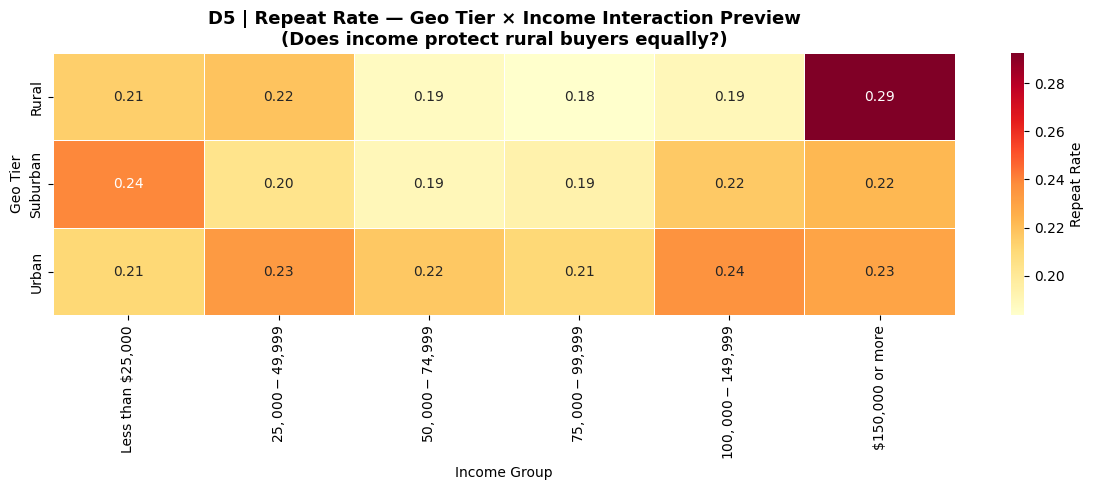

In [58]:
h_df = df.dropna(subset=["income","geo_label","repeat_same_product_flag"])
income_order = ["Less than $25,000","$25,000 - $49,999","$50,000 - $74,999",
                "$75,000 - $99,999","$100,000 - $149,999","$150,000 or more"]
income_order = [i for i in income_order if i in h_df["income"].unique()]

pivot = (h_df.groupby(["geo_label","income"])["repeat_same_product_flag"]
             .mean()
             .unstack()
             .reindex(columns=income_order))

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label":"Repeat Rate"})
plt.title("D5 | Repeat Rate — Geo Tier × Income Interaction Preview\n"
          "(Does income protect rural buyers equally?)", fontsize=13, fontweight='bold')
plt.xlabel("Income Group")
plt.ylabel("Geo Tier")
plt.tight_layout()
plt.show()

***Note:***

This heatmap is one of the most interesting charts in the project.

Rural buyers show larger variation across income groups:

* high-income rural buyers repeat more
* middle-income rural buyers repeat less
* lower-income rural buyers stay somewhere in between

Semi-urban groups show a similar shape.

Urban buyers, however, look more stable across income levels. My assumption is that urban customers already have easier access to online shopping infrastructure, so income creates less behavioral difference there compared to rural regions.

### *D6 - Seasonal Pattern by Geo Tier*

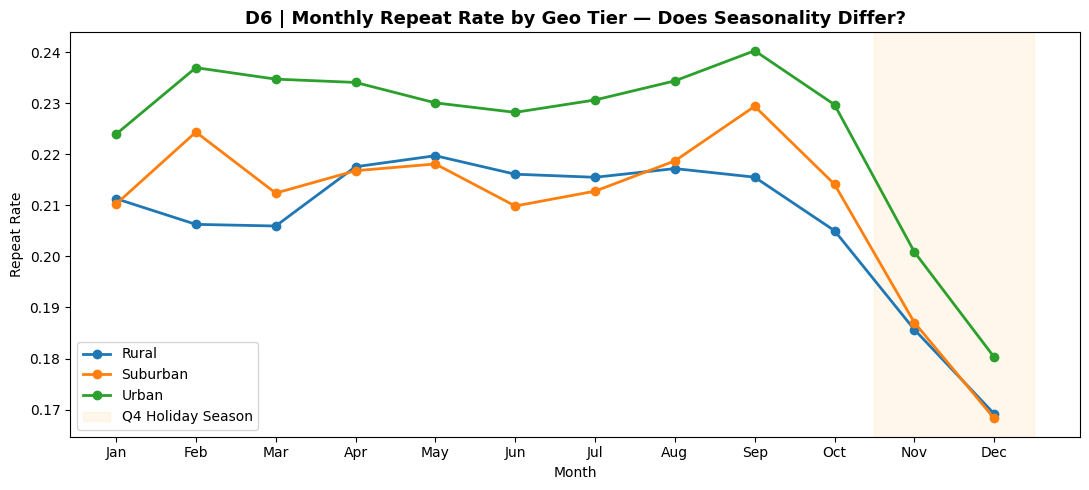

In [59]:
monthly_geo = (df.dropna(subset=["geo_label","repeat_same_product_flag"])
                .groupby(["order_month","geo_label"])["repeat_same_product_flag"]
                .mean()
                .unstack())

plt.figure(figsize=(11, 5))
for geo in monthly_geo.columns:
    plt.plot(monthly_geo.index, monthly_geo[geo], marker="o", label=geo, linewidth=2)
plt.axvspan(10.5, 12.5, alpha=0.08, color="orange", label="Q4 Holiday Season")
plt.title("D6 | Monthly Repeat Rate by Geo Tier — Does Seasonality Differ?",
          fontsize=13, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Repeat Rate")
plt.xticks(range(1,13), ["Jan","Feb","Mar","Apr","May","Jun",
                           "Jul","Aug","Sep","Oct","Nov","Dec"])
plt.legend()
plt.tight_layout()
plt.show()

***Note:***

This chart combines geography and seasonality together.

Urban customers generally maintain slightly higher repeat rates throughout the year. Rural and semi-urban lines often overlap and cross each other, which suggests their seasonal behavior is quite similar.

The instability around January and February may reflect:

* post-holiday spending fatigue
* Valentine’s season shopping
* changing buying priorities after December gifting periods

Overall, the seasonal effect exists, but geography still does not create a massive separation.

---

#### **EDA SUMMARY**
After exploring all the charts, one conclusion becomes very clear:
repeat purchasing is driven more by product behavior than by geography alone.

Category, routine consumption, affordability, and buying purpose explain much more than rural-versus-urban differences. Geography still plays a role, but the gap is smaller than expected.

The charts also helped explain why the later hypothesis tests behave the way they do:

* significant p-values appear because the dataset is huge
* effect sizes stay small because the actual behavior gap is modest
* category stays dominant because repeat buying is naturally product-driven

So before even running formal hypothesis testing, the EDA already hints at the final story:
the "rural disadvantage" idea exists a little, but it is much weaker than the marketplace-product effect.

## E | **HYPOTHESIS TESTING**

Non‑parametric tests are useful when the data is not normal or when the groups are uneven. They are safer because they can handle skewed data and outliers better. This way, the results are more reliable even if the data is messy.

* **Chi‑square test:**  
Used for categorical data. It checks if two categories are independent or not. I add ***Cramér’s V*** to show how strong the link is, with values between 0 and 1.

* **Mann‑Whitney U:**  
Used for comparing two groups of numbers when the data is not normal. It works well with outliers. I use ***rank‑biserial r*** to show both the size and the direction of the difference.

* **Logistic regression:**  
Different from the others because it lets me study more than one factor at the same time. It shows the independent effect of each variable while controlling for the others.

***Note:***  
 Chi-square looks at one factor at a time. It cannot tell you whether geography still matters once you account for income, price, and quantity. Logistic regression can. It takes multiple variables simultaneously and estimates the independent contribution of each one to the probability of a repeat purchase. The coefficients itproduces are converted into odds ratios.

---


In [60]:
def cramers_v(x, y):
    """Calculate Cramer's V statistic to measure association between two
    categorical variables.

    Returns:
    tuple: (chi2 statistic, p-value, Cramer's V, contingency table)
    """

    table = pd.crosstab(x, y)
    chi2, p, dof, expected = stats.chi2_contingency(table)
    n = table.to_numpy().sum()
    r, c = table.shape
    v = np.sqrt(chi2 / (n * min(r - 1, c - 1))) if min(r - 1, c - 1) > 0 else np.nan
    return chi2, p, v, table

def rank_biserial_from_u(u, n1, n2):
    '''
    Compute the Rank-Biserial Correlation effect size from a Mann-Whitney U statistic
    '''

    return 1 - (2 * u) / (n1 * n2)

def plot_repeat_rate_bar(data, x, y="repeat_same_product_flag", title=""):
    plt.figure(figsize=(9, 4))
    sns.barplot(data=data, x=x, y=y, estimator=np.mean, errorbar=None)
    plt.title(title)
    plt.ylabel("Repeat rate")
    plt.xlabel(x)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

def plot_box(data, x, y, title=""):
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=data, x=x, y=y)
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()

### *H1:  Does customer location affect the repeat purchase?*

The bar chart showed a slight drop in repeat rates from urban to rural customers. I wanted to see if that drop was statistically meaningful or just sampling noise.

* **Null hypothesis:** There’s no link between customer location and repeat buying.

* **Alternative hypothesis:** Customer location does affect repeat buying.

In [64]:
## This takes your dictionary and forces it into a perfectly indented, multi-line string.
import json

h1_df = df.dropna(subset=["geo_label", "repeat_same_product_flag"]).copy()

chi2_h1, p_h1, cv_h1, tab_h1 = cramers_v(h1_df["geo_label"], h1_df["repeat_same_product_flag"])

# 1. Create a clean dictionary.
results = {
    "test": "chi-square",
    "chi2": chi2_h1,
    "p_value": p_h1,
    "cramers_v": cv_h1,
}

# 2. Print using json.dumps to lock in the order.
# (Note: we use a helper to handle NumPy types so json doesn't throw an error).
print('H1: Result','\n',json.dumps(results, indent=4))

print('\n',tab_h1)



H1: Result 
 {
    "test": "chi-square",
    "chi2": 634.798011046435,
    "p_value": 1.4300899007610715e-138,
    "cramers_v": 0.018976134866006543
}

 repeat_same_product_flag       0       1
geo_label                               
Rural                     102505   26582
Suburban                  550169  145082
Urban                     728441  210090


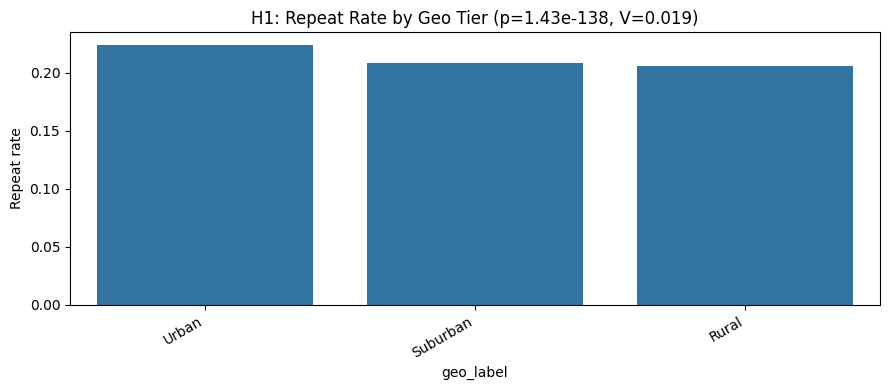

In [78]:
plot_repeat_rate_bar(h1_df, "geo_label", title=f"H1: Repeat Rate by Geo Tier (p={p_h1:.3g}, V={cv_h1:.3f})")


***Decision:***  
*We reject the null hypothesis.*

The chi‑square value of " **634.79**" with a p‑value that is basically "**0**" shows this pattern did not happen by chance. Geography and repeat purchasing are connected. But Cramer's V is only " **0.019**", which is in the negligible range. This means the link is real but very weak.

The bar chart shows Urban buyers repeating a little more than Rural buyers, but the gap is so small that it would not make sense to build a business strategy around it.

### *H2. Do rural customers take more time before making another purchase?*

I compared the gap in days between two purchases of the same product for urban and rural customers.

* **Null hypothesis:** Urban and rural customers have the same repeat‑gap distribution.

* **Alternative hypothesis:** Urban and rural customers show different repeat‑gap distributions.

In [65]:
h2_df = df[df["geo_tier"].isin([1, 3])].dropna(subset=["geo_tier", "repeat_gap_days"]).copy()

g1 = h2_df.loc[h2_df["geo_tier"] == 1, "repeat_gap_days"]
g3 = h2_df.loc[h2_df["geo_tier"] == 3, "repeat_gap_days"]

u_h2, p_h2 = stats.mannwhitneyu(g1, g3, alternative="two-sided")
rb_h2 = rank_biserial_from_u(u_h2, len(g1), len(g3))

results = {
    "test": "Mann-Whitney U",
    "u_stat": u_h2,
    "p_value": p_h2,
    "rank_biserial_r": rb_h2,
    "median_tier1": g1.median(),
    "median_tier3": g3.median(),
    "mean_tier1": g1.mean(),
    "mean_tier3": g3.mean()
}

print('H2: Result','\n',json.dumps(results, indent=4))



H2: Result 
 {
    "test": "Mann-Whitney U",
    "u_stat": 61345906781.0,
    "p_value": 6.742490496854257e-33,
    "rank_biserial_r": -0.01270850207600871,
    "median_tier1": 0.0,
    "median_tier3": 0.0,
    "mean_tier1": 20.15893028573377,
    "mean_tier3": 19.285845979843053
}


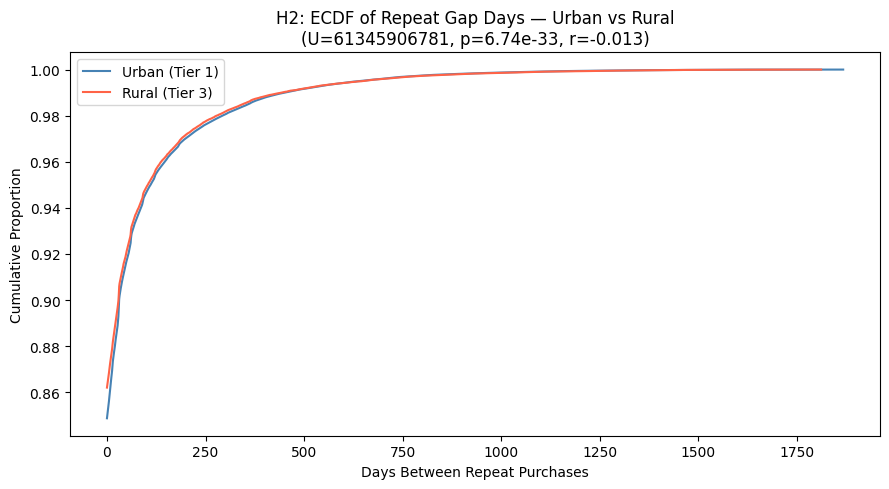

In [ ]:
from scipy.stats import ecdf

fig, ax = plt.subplots(figsize=(9, 5))
for tier, label, color in [(1, "Urban (Tier 1)", "steelblue"), (3, "Rural (Tier 3)", "tomato")]:
    x = h2_df.loc[h2_df["geo_tier"] == tier, "repeat_gap_days"].dropna()
    res = ecdf(x)
    ax.plot(res.cdf.quantiles, res.cdf.probabilities, label=label, color=color)

ax.set_title(f"H2: ECDF of Repeat Gap Days — Urban vs Rural\n(U={u_h2:.0f}, p={p_h2:.3g}, r={rb_h2:.3f})")
ax.set_xlabel("Days Between Repeat Purchases")
ax.set_ylabel("Cumulative Proportion")
ax.legend()
plt.tight_layout()
plt.show()

***Decision:***  
*We reject the null hypothesis.*

The p‑value is significant, which means the test detects a difference. But the rank‑biserial r is " **- 0.013**", and that number is the one that really matters. At that level, the effect is so small it is basically zero. Both groups have a median repeat gap of **0 days**, which means the usual pattern is no gap at all between repeat purchases of the same product.

The **Empirical Cumulative Distribution Function (ECDF)** chart makes this even clearer. The two curves for Urban and Rural customers sit almost exactly on top of each other across the entire range of gap days. With **1.85 million** rows, the Mann‑Whitney U test is sensitive enough to pick up very tiny differences, but in this case the difference is only microscopic.

So the association is statistically significant but the effect size is negligible (**r = - 0.013**). Rural customers do not meaningfully wait longer to repeat purchase.

### *H3. Does income level affect repeat purchases?*

The income chart showed a clear upward trend.
* **Null hypothesis**: Income group doesn’t affect whether people buy again.
* **Alternative hypothesis**: Income group does affect repeat buying.

In [66]:
h3_df = df.dropna(subset=["income", "repeat_same_product_flag"]).copy()

chi2_h3, p_h3, cv_h3, tab_h3 = cramers_v(h3_df["income"], h3_df["repeat_same_product_flag"])

results = {"test": "chi-square", "chi2": chi2_h3, "p_value": p_h3, "cramers_v": cv_h3}
print('H3 Results:', '\n', json.dumps(results, indent=4))
print('\n',tab_h3)

H3 Results: 
 {
    "test": "chi-square",
    "chi2": 1194.320707579025,
    "p_value": 8.1125989128615535e-255,
    "cramers_v": 0.02540331971214463
}

 repeat_same_product_flag       0      1
income                                 
$100,000 - $149,999       298605  90820
$150,000 or more          189109  61251
$25,000 - $49,999         268562  80751
$50,000 - $74,999         289509  79887
$75,000 - $99,999         233677  64224
Less than $25,000         133232  41138
Prefer not to say          14766   5186


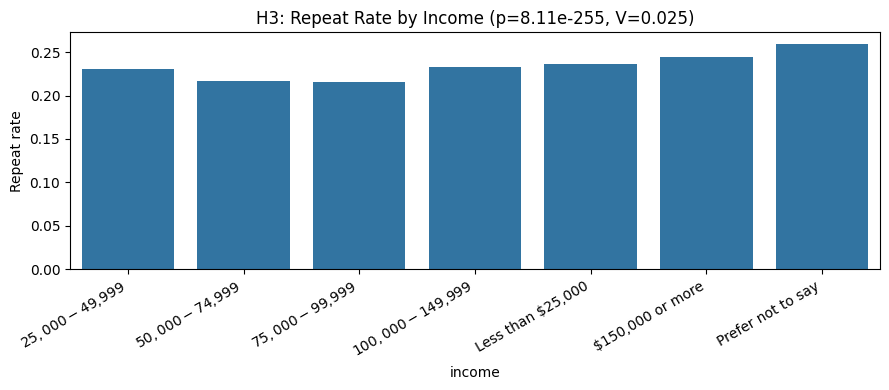

In [76]:
plot_repeat_rate_bar(h3_df, "income", title=f"H3: Repeat Rate by Income (p={p_h3:.3g}, V={cv_h3:.3f})")

***Decision:***  
*We reject the null hypothesis.*

Income and repeat purchasing are connected. The chi‑square value is large, and the p‑value is basically "**0**", so the result is statistically significant. But Cramer's V is only " **0.025**", which means the strength of the link is very small.

The bar chart shows that repeat rates across income groups are almost flat. Most groups are between **21 %** and **27 %**. High earners repeat a little more, very low earners repeat a little less, but the differences are small.

Income is real as a factor, but it is not the main driver of repeat buying. The effect is statistically significant but practically negligible.

### *H4. Does product category affect repeat purchase?*

In the EDA, some product categories had repeat rates above seventy percent, while others were below ten. I focused on the top ten categories.

* **Null hypothesis:** Product category doesn’t affect whether people buy again.
* **Alternative hypothesis:** Product category does affect repeat buying.



In [68]:
h4_top = df["category"].value_counts().head(10).index
h4_df = df[df["category"].isin(h4_top)].dropna(subset=["category", "repeat_same_product_flag"]).copy()

chi2_h4, p_h4, cv_h4, tab_h4 = cramers_v(h4_df["category"], h4_df["repeat_same_product_flag"])

results = {"test": "chi-square", "chi2": chi2_h4, "p_value": p_h4, "cramers_v": cv_h4}
print('H4 Results:', '\n', json.dumps(results, indent=4))

print('\n',tab_h4)

H4 Results: 
 {
    "test": "chi-square",
    "chi2": 117796.8923513517,
    "p_value": 0.0,
    "cramers_v": 0.6371364188401675
}

 repeat_same_product_flag      0      1
category                              
ABIS_BOOK                 82626   4993
CELLULAR_PHONE_CASE       14454    916
ELECTRONIC_CABLE          16143   2125
GIFT_CARD                  5837  21897
HEALTH_PERSONAL_CARE      10565   6060
MEDICATION                 8817   7368
NUTRITIONAL_SUPPLEMENT    11653  15260
PANTS                     14388   1556
PET_FOOD                  10033  28223
SHIRT                     25603   1664


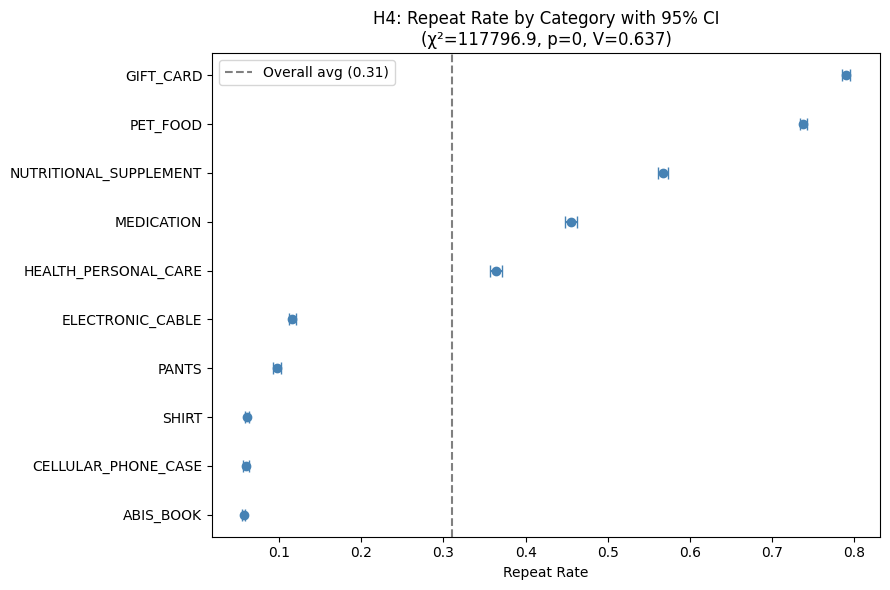

In [ ]:
import scipy.stats as stats

cat_stats = []
for cat in h4_df["category"].unique():
    sub = h4_df[h4_df["category"] == cat]["repeat_same_product_flag"]
    n = len(sub)
    p = sub.mean()
    se = np.sqrt(p * (1 - p) / n)
    ci = 1.96 * se
    cat_stats.append({"category": cat, "repeat_rate": p, "ci": ci, "n": n})

cat_df = pd.DataFrame(cat_stats).sort_values("repeat_rate", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(cat_df["repeat_rate"], cat_df["category"],
            xerr=cat_df["ci"], fmt="o", color="steelblue", capsize=4)
overall_rate = h4_df["repeat_same_product_flag"].mean()
ax.axvline(overall_rate, linestyle="--", color="grey", label=f"Overall avg ({overall_rate:.2f})")
ax.set_title(f"H4: Repeat Rate by Category with 95% CI\n(χ²={chi2_h4:.1f}, p={p_h4:.3g}, V={cv_h4:.3f})")
ax.set_xlabel("Repeat Rate")
ax.legend()
plt.tight_layout()
plt.show()

***Decision:***  
*We reject the null hypothesis.*

Category has a very strong effect on repeat purchasing. Cramer's V is " **0.637**", which is not weak or moderate but clearly strong. The bar chart shows this in a dramatic way. Gift cards and pet food have repeat rates above " **75 %**", while books and phone cases are below " **10 %**". The gap between the highest and lowest category is more than " **70 %**" points.

This is very different from the geography result, where the difference between tiers was only a few percentage points. Category is not just related to repeat buying. It almost defines it. A customer’s chance of buying the same thing again is shaped first and most strongly by what the product is.

### *H5. Do price ranges affect repeat buying?*

I split unit price into four bands and checked whether cheaper items tend to be bought again more often.

* **Null hypothesis:** Price band doesn’t affect repeat buying.

* **Alternative hypothesis:** Price band does affect repeat buying.

In [69]:
h5_df = df.dropna(subset=["price_bin", "repeat_same_product_flag"]).copy()

chi2_h5, p_h5, cv_h5, tab_h5 = cramers_v(h5_df["price_bin"], h5_df["repeat_same_product_flag"])

results = {"test": "chi-square", "chi2": chi2_h5, "p_value": p_h5, "cramers_v": cv_h5}
print('H5 Results:', '\n', json.dumps(results, indent=4))
print('\n',tab_h5)


H5 Results: 
 {
    "test": "chi-square",
    "chi2": 19910.578664840774,
    "p_value": 0.0,
    "cramers_v": 0.10372225115046081
}

 repeat_same_product_flag       0       1
price_bin                               
Low                       322339  140504
Mid                       378896   95145
High                      355372   95884
Premium                   370853   91724


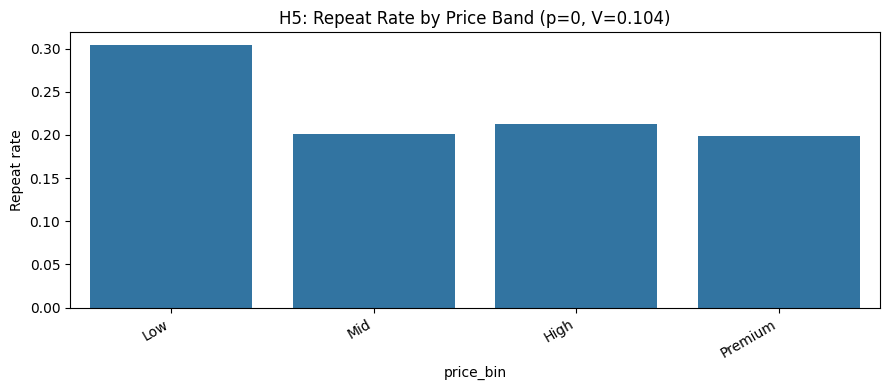

In [74]:
plot_repeat_rate_bar(h5_df, "price_bin", title=f"H5: Repeat Rate by Price Band (p={p_h5:.3g}, V={cv_h5:.3f})")

***Decision:***
*We reject the null hypothesis.*

Price band and repeat purchasing are connected. Cramer's V is " **0.104**", which is in the weak to moderate range. This means the effect is real. It is stronger than the geography or income effects, but still smaller than the category effect.

The chart shows a clear pattern. The low price band has a repeat rate of about " **30 %**". The mid, high, and premium bands are all close to " **20 %**". Cheap everyday items such as cleaning supplies or pantry staples are bought again more often. Expensive one time purchases are not.

The price effect is partly explained by category, because low priced consumable items are often in categories that naturally have high repeat rates.

### *H6. Does the month of purchase influence repeat buying?*

The data showed a seasonal rise in November and December, so I wanted to check that with a proper test.

* **Null hypothesis:** The month of purchase doesn’t affect whether people buy again.

* **Alternative hypothesis:** The month of purchase does affect repeat buying.

In [70]:
h6_df = df.dropna(subset=["order_month", "repeat_same_product_flag"]).copy()

chi2_h6, p_h6, cv_h6, tab_h6 = cramers_v(
    h6_df["order_month"].astype(str),
    h6_df["repeat_same_product_flag"]
)

resulst = {"test": "chi-square", "chi2": chi2_h6, "p_value": p_h6, "cramers_v": cv_h6}
print('H6 Results:', '\n', json.dumps(resulst, indent=4))
print('\n',tab_h6)


H6 Results: 
 {
    "test": "chi-square",
    "chi2": 3164.19298123077,
    "p_value": 0.0,
    "cramers_v": 0.041348663286075074
}

 repeat_same_product_flag       0      1
order_month                            
1                         120132  35765
10                        117108  35734
11                        138386  35760
12                        156211  35934
2                         104954  33575
3                         115285  35490
4                         107312  33644
5                         111014  34305
6                         114049  34987
7                         119611  36483
8                         116919  36767
9                         106479  34813


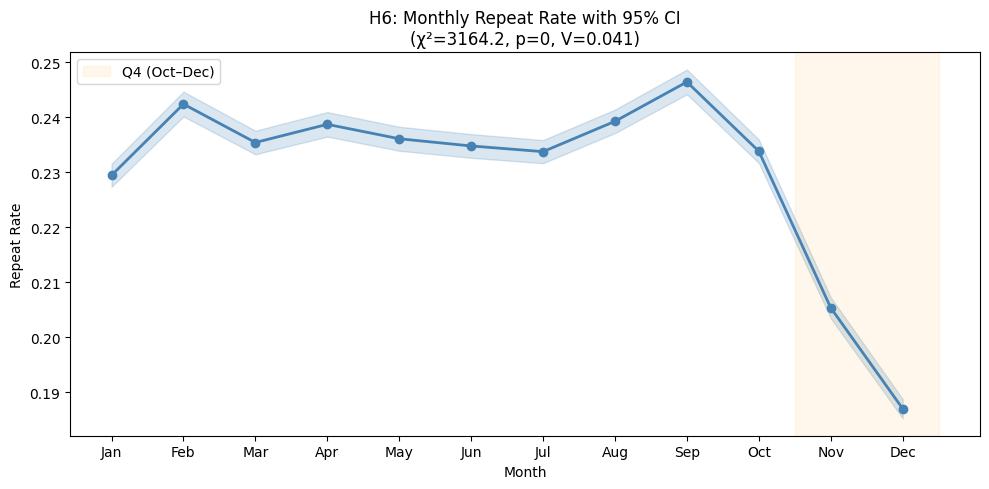

In [73]:
month_stats = []
for m in sorted(h6_df["order_month"].unique()):
    sub = h6_df[h6_df["order_month"] == m]["repeat_same_product_flag"]
    p = sub.mean()
    se = np.sqrt(p * (1 - p) / len(sub))
    month_stats.append({"month": m, "rate": p, "ci": 1.96 * se})

ms = pd.DataFrame(month_stats)

plt.figure(figsize=(10, 5))
plt.plot(ms["month"], ms["rate"], marker="o", color="steelblue", linewidth=2)
plt.fill_between(ms["month"], ms["rate"] - ms["ci"], ms["rate"] + ms["ci"],
                 alpha=0.2, color="steelblue")
plt.axvspan(10.5, 12.5, alpha=0.08, color="orange", label="Q4 (Oct–Dec)")
plt.title(f"H6: Monthly Repeat Rate with 95% CI\n(χ²={chi2_h6:.1f}, p={p_h6:.3g}, V={cv_h6:.3f})")
plt.xlabel("Month")
plt.ylabel("Repeat Rate")
plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun",
                            "Jul","Aug","Sep","Oct","Nov","Dec"])
plt.legend()
plt.tight_layout()
plt.show()

***Decision:***
*We reject the null hypothesis.*

Month and repeat purchasing are connected, and the pattern in the chart is clear. Repeat rates stay fairly steady from January to September, reaching a peak around September at about " **25 %**". After that, they drop sharply. November falls to about " **21 %**", and December goes below " **19 %**".

The holiday season in the last quarter is usually the busiest time for e‑commerce, and it is in terms of total sales. But that extra volume comes from new purchases, not from customers coming back to buy the same product again.

The effect size is " **0.041**", which is weak. This means month by itself is not a strong predictor of repeat buying. Still, the seasonal dip is a real pattern worth noticing.

### *H7. Do location and income together drive repeat buying behavior?*

The heatmap in D4 showed that the rural‑urban gap gets smaller at higher income levels. To check that more formally, I ran a logistic regression with interaction terms, while also controlling for unit price and quantity.

* **Null hypothesis:** Adding location, income, and their interaction (plus controls) doesn’t help the model predict repeat purchases any better than having no predictors at all.

* **Alternative hypothesis:** Including those factors makes the model a better fit.

In [71]:
h7_df = df.dropna(subset=[
    "repeat_same_product_flag", "geo_label", "income", "unit_price", "quantity"
]).copy()

h7_df["repeat_same_product_flag"] = h7_df["repeat_same_product_flag"].astype(int)

model = smf.logit(
    "repeat_same_product_flag ~ C(geo_label) * C(income) + unit_price + quantity",
    data=h7_df
).fit(disp=False)

proba = model.predict(h7_df)
pred = (proba >= 0.5).astype(int)

auc = roc_auc_score(h7_df["repeat_same_product_flag"], proba)
acc = accuracy_score(h7_df["repeat_same_product_flag"], pred)
bacc = balanced_accuracy_score(h7_df["repeat_same_product_flag"], pred)
f1 = f1_score(h7_df["repeat_same_product_flag"], pred)

print(model.summary())
results = {
    "aic": model.aic,
    "bic": model.bic,
    "pseudo_r2": 1 - model.llf / model.llnull,
    "auc": auc,
    "accuracy": acc,
    "balanced_accuracy": bacc,
    "f1": f1
}

print('\n','H7 Results:', '\n', json.dumps(results, indent=4))

                              Logit Regression Results                              
Dep. Variable:     repeat_same_product_flag   No. Observations:              1762869
Model:                                Logit   Df Residuals:                  1762846
Method:                                 MLE   Df Model:                           22
Date:                      Tue, 19 May 2026   Pseudo R-squ.:                 0.01783
Time:                              16:07:56   Log-Likelihood:            -9.0470e+05
converged:                             True   LL-Null:                   -9.2112e+05
Covariance Type:                  nonrobust   LLR p-value:                     0.000
                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                  -1.8225      

***Note:***

The overall model was statistically significant, with a likelihood ratio & p‑value of "`0`".

The interaction terms were significant as well. The model's pseudo R‑squared was only "`0.018`",

And the AUC was "`0.589`", meaning it predicts repeat purchases only slightly better than random.

#### **H7 visualization 1: Odds ratio plot**

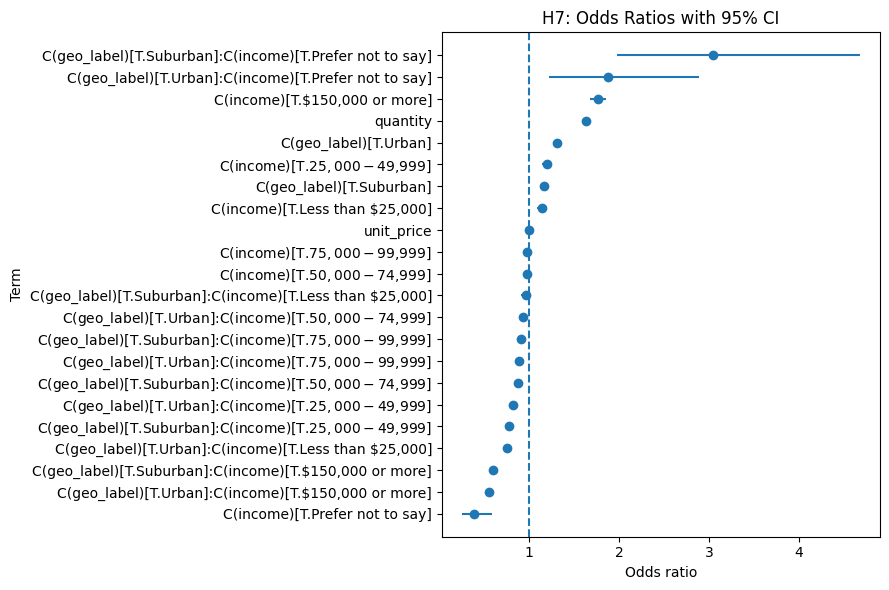

In [ ]:
or_df = pd.DataFrame({
    "term": model.params.index,
    "or": np.exp(model.params.values),
    "low": np.exp(model.conf_int()[0].values),
    "high": np.exp(model.conf_int()[1].values)
})

or_df = or_df[or_df["term"] != "Intercept"].sort_values("or")

plt.figure(figsize=(9, 6))
plt.errorbar(or_df["or"], or_df["term"],
             xerr=[or_df["or"] - or_df["low"], or_df["high"] - or_df["or"]],
             fmt="o")
plt.axvline(1, linestyle="--")
plt.title("H7: Odds Ratios with 95% CI")
plt.xlabel("Odds ratio")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

It proving that buying a larger item quantity or having a high income strongly drives repeat buying. It also acted as a safety warning, revealing that we cannot trust the data for rare groups (like people with unknown incomes) because their wide confidence intervals show high mathematical uncertainty.



#### **H7 visualization 2: ROC curve**

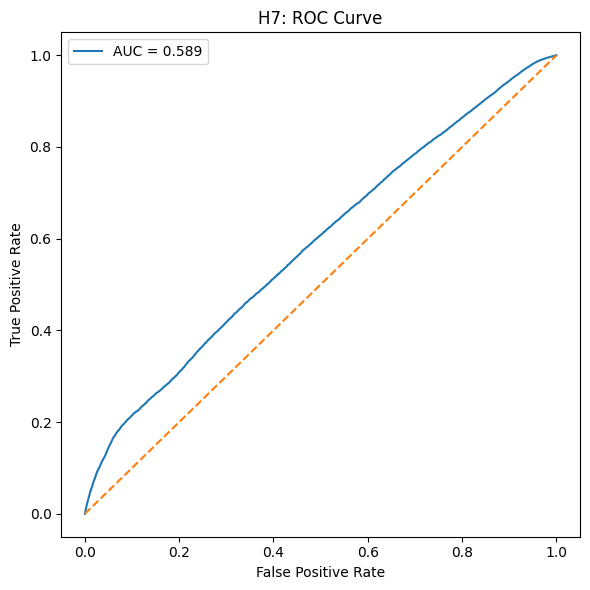

In [ ]:
fpr, tpr, _ = roc_curve(h7_df["repeat_same_product_flag"], proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("H7: ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

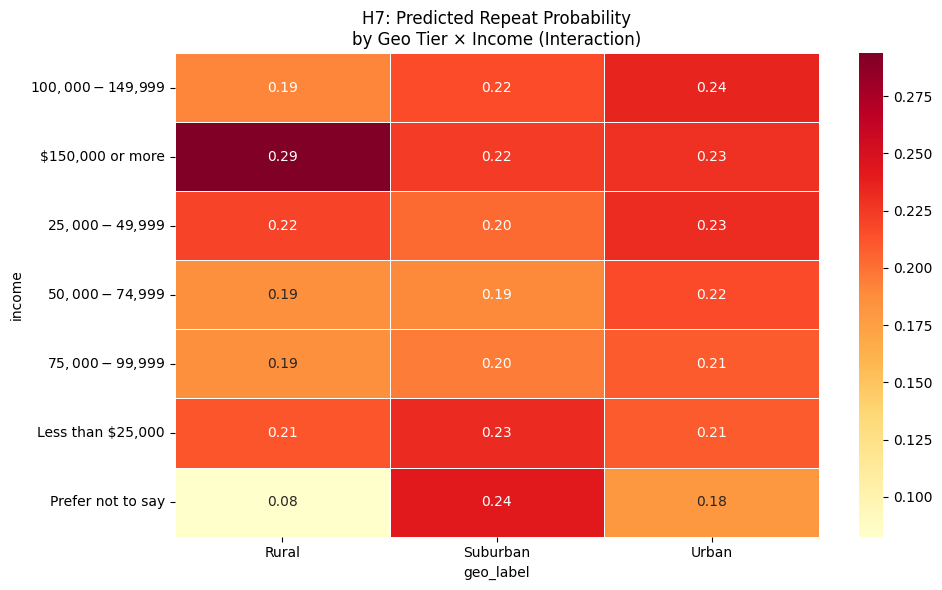

In [ ]:
from itertools import product as iproduct

geo_cats = h7_df["geo_label"].unique()
inc_cats = h7_df["income"].dropna().unique()

grid = pd.DataFrame(list(iproduct(geo_cats, inc_cats)),
                    columns=["geo_label", "income"])
grid["unit_price"] = h7_df["unit_price"].median()
grid["quantity"]   = h7_df["quantity"].median()
grid["pred_prob"]  = model.predict(grid)

pivot = grid.pivot(index="income", columns="geo_label", values="pred_prob")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("H7: Predicted Repeat Probability\nby Geo Tier × Income (Interaction)")
plt.tight_layout()
plt.show()

It clearly shows that Wealthy Rural buyers have the highest repeat chance (29%). while Rural Unknown-Income buyers have the lowest (8%), while also proving that income matters a lot in the countryside but has almost no impact in cities and suburbans.

---

***Decision:***  
*We reject the null hypothesis.*

Geographic tier does have an effect on repeat purchasing, even after we take income, price, and quantity into account. The interaction with income is also real because the coefficients on those interaction terms are significant.

But the result is very small. The pseudo R squared is only "**1.78 %**". This means geography, income, price, and quantity together  explain " **> 2 %**" of why someone buys again.

So the patterns are real, but they are weak. Most of what makes people repeat a purchase, such as product quality, personal habits, or how satisfied they felt with the experience, is not included in this dataset.

---

## F | **SUMMARY & FINDINGS**

This project started with a simple question:  
**Do rural customers really behave differently from urban customers in e‑commerce, or is that just an assumption?**

To test this, I used more than **1.85 million Amazon orders** from the Harvard Dataverse, linked them with survey data and state population density, and built repeat‑purchase features. The goal was to see what actually drives repeat buying when geography, income, category, price, and seasonality all interact.

**What the data showed was surprising.**  
At first, geography looked important because the p‑values were extremely small. But once I checked effect sizes, the differences between rural and urban buyers turned out to be very small. Rural customers were not behaving dramatically differently.

From the exploratory analysis, two clear patterns stood out:  
- Repeat purchases were **skewed,** like most happened quickly, while a smaller group repeated after long gaps.  
- Prices were also **skewed,** like most items were low‑priced, with a few expensive products stretching the distribution.  

This explained why log‑price features and non‑parametric tests were needed later.

The repeat‑rate charts made the main point clear:  
**Repeat behavior is shaped more by what people buy than where they live.**

- **Category** was the strongest driver. Gift cards, pet products, and pharmacy items had very high repeat rates because they are tied to routine needs, subscriptions, birthdays, and monthly care. Books and phone cases had very low repeat rates because they are one‑time purchases.  
- **Geography** showed only weak differences. Urban buyers repeated slightly more and slightly faster, but the gap was small.  
- **Income** had a small effect. Higher earners repeated a bit more, but not enough to be a main driver.  
- **Price band** and **seasonality** added moderate patterns. Low‑priced items repeated more, and holiday months showed fewer repeats because people were buying gifts instead of restocking.  
- The **final model** combining geography, income, price, and quantity explained only 1.78% of behavior. The ROC score was barely better than chance, showing that customer decisions are far more complex than these variables alone.

**The most important takeaway:**  
Customer behavior in e‑commerce is not controlled by one simple factor. Geography matters a little. Income matters a little. Seasonality matters a little. But **product category is the strongest signal**. Rural customers are not systematically less loyal, the real difference comes from what they buy.  

---